In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import glob
import os
from pprint import pprint

from decimal import Decimal
plt.rcParams['font.size'] = 15

def print_config(config):
    pprint(vars(config), indent=4)

In [2]:
def reject_outliers(grad, loss, m=3):
    ## data (nsp, nbt)
    ## if any sample is outlier, report which batches and filter them out
    del_bt_grad = np.unique(np.where(abs(grad-np.nanmedian(grad, axis=1)[:,None])>m*np.nanstd(grad, axis=1)[:,None])[1])
    del_bt_loss = np.unique(np.where(abs(loss-np.nanmedian(loss, axis=1)[:,None])>m*np.nanstd(loss, axis=1)[:,None])[1])
    del_bt = np.unique(np.concatenate([del_bt_grad, del_bt_loss]))
    print(f"Outlier batch {del_bt}")
    new_grad = np.delete(grad, (del_bt), axis=1)
    new_loss = np.delete(loss, (del_bt), axis=1)
    print(f"Remaining number of batches: {new_grad.shape[1]}")

    return new_grad, new_loss, del_bt

In [3]:
def find_closest_arg(arr, value):
    """
    Finds the argument in the list closest to the given value.

    Args:
        args: A list of numerical arguments.
        value: The numerical value to compare against.

    Returns:
        The argument in the list that is closest to the value.
    """

    min_difference = abs(arr[0] - value)

    for i, v in enumerate(arr):
        difference = abs(v - value)
        if difference < min_difference:
            min_difference = difference
            pos = i

    return pos

In [4]:
# Making 8 plots for each scan 
# 0: plot all in dots  | 1: median           | 2: mean  
# 3: plot cleaned dots | 4: cleaned median   | 5: cleaned mean
def plot_gradient_scan(fname, n_std = 3):
    # fig, axs = plt.subplots(2, 3, figsize=(20, 15))
    fig, axs = plt.subplots(1, 3, figsize=(20, 7))
    with open(fname, 'rb') as f:
        results = pickle.load(f)    
    # print_config(results['config'])    
    params = [key.replace('_grad', '') for key in results.keys() if '_grad' in key]
    nb_params = len(params)
    assert(nb_params == 1)
    param = params[0]

    target = results[f"{param}_target"]

    global st_bt
    global st_iter
    global st_nbt
    global st_nsp
    global st_lr
    st_bt = vars(results['config'])['max_batch_len']
    st_iter = vars(results['config'])['iterations']    
    st_lr = vars(results['config'])['lr']    

    # param_value = np.average(np.array(results[f"{param}_iter"][1:max_index + 1]).reshape(-1, nbatches), axis=1)
    param_value = np.sort(np.unique(results[f"{param}_iter"][1:]))
    nbatches = np.count_nonzero(results[f"{param}_iter"] == param_value[0])
    st_nbt = nbatches  

    max_index = (len(results["losses_iter"])//nbatches)*nbatches
    # param_value = np.average(np.array(results[f"{param}_iter"][1:max_index + 1]).reshape(-1, nbatches), axis=1)

    # grad = np.array(results[f"{param}_grad"][:max_index]).reshape(-1, nbatches)
    # loss = np.array(results["losses_iter"][:max_index]).reshape(-1, nbatches)
    grad = np.array(results[f"{param}_grad"][:max_index]).reshape(nbatches, -1).T
    loss = np.array(results["losses_iter"][:max_index]).reshape(nbatches, -1).T
    
    grad_median = np.nanmedian(grad, axis=1)
    loss_median = np.nanmedian(loss, axis=1)

    grad_mean = np.nanmean(grad, axis=1)
    loss_mean = np.nanmean(loss, axis=1)

    clean_grad, clean_loss, out_bt = reject_outliers(grad, loss, n_std)

    clean_grad_median = np.nanmedian(clean_grad, axis=1)
    clean_loss_median = np.nanmedian(clean_loss, axis=1)

    clean_grad_mean = np.nanmean(clean_grad, axis=1)
    clean_loss_mean = np.nanmean(clean_loss, axis=1)

    st_nsp = grad.shape[0]

    # for i_plt in range(6):
    for i_plt in range(3):
        loss_min = ""
        gradient0 = ""
        style = "-"
        ax = axs[i_plt%3]
        # ax = axs[i_plt//3, i_plt%3]
        if i_plt == 0:
            this_grad = grad
            this_loss = loss
            style = "."
        elif i_plt == 1:
            this_grad = grad_median
            this_loss = loss_median  
        elif i_plt == 2:
            this_grad = grad_mean
            this_loss = loss_mean
        elif i_plt == 3:
            this_grad = clean_grad
            this_loss = clean_loss
            style = "."
        elif i_plt == 4:
            this_grad = clean_grad_median
            this_loss = clean_loss_median
        elif i_plt == 5:
            this_grad = clean_grad_mean
            this_loss = clean_loss_mean

        if i_plt in [1,2,4,5]:
            v_target = results[f'{param}_target'][0]
            v_loss_min = param_value[np.argmin(this_loss)]
            if param != "shift_z":
                off_loss_min = (v_loss_min - v_target) / v_target * 100
                s_off_loss_min = f"{off_loss_min:.2f}%"
            else:
                off_loss_min = (v_loss_min - v_target)
                s_off_loss_min = f"{off_loss_min:.2f}"
            v_gradient0 = param_value[np.argmin(abs(this_grad))]
            if param != "shift_z":
                off_gradient0 = (v_gradient0 - v_target) / v_target * 100
                s_off_gradient0 = f"{off_gradient0:.2f}%"
            else:
                off_gradient0 = (v_gradient0 - v_target)
                s_off_gradient0 = f"{off_gradient0:.2f}"
            loss_min = f" min: {np.min(this_loss):.2f} at {param} {Decimal(v_loss_min):.3E} \n (target: {Decimal(v_target):.3E}, offset {s_off_loss_min})"
            loss_min = f" min: {np.min(this_loss):.2f} at {param} {Decimal(v_loss_min):.3E}"
            gradient0 = f" ~0 at {param} {Decimal(v_gradient0):.3E} \n (target: {Decimal(v_target):.3E}, offset {s_off_gradient0})"
            gradient0 = f" ~0 at {param} {Decimal(v_gradient0):.3E}"
            ####################
            if i_plt == 2:
                print("loss min: ", np.min(this_loss))
                print("loss at target: ", this_loss[find_closest_arg(param_value, v_target)])
                print("loss at gradient 0:", this_loss[np.argmin(abs(this_grad))])
        
        l1 = ax.plot(param_value, this_grad, style, label=f"gradient{gradient0}")
        ax2 = ax.twinx()
        ax2.tick_params(axis='y', colors='green')
        ax.tick_params(axis='y', colors='C0')

        l2 = ax2.plot(param_value, this_loss, style, color='green', label=f"loss{loss_min}")
        l3 = ax.axvline(target, color='red', linestyle="--", label=f'target at {target}')
        l4 = ax.axhline(0, color='gray', linestyle="--", label='target')
    
        # lns = l1 + l2
        lns = l1 + l2 + [l3]
        labs = [l.get_label() for l in lns]
        
        # if i_plt in [1,4]:
        #     lg = ax2.legend(lns, labs, title="median", loc="upper right")
        # elif i_plt in [2,5]:
        #     lg = ax2.legend(lns, labs, title="mean", loc="upper right")

        if i_plt == 1:
            ax.set_title(f"loss and gradient scan with {st_nbt} batches of {st_bt} cm")
        if i_plt == 4:
            ax.set_title(f"removed {len(out_bt)} outlier batches {out_bt}")
        ax.set_xlabel(param)
        # ax.set_xlim([results[f'{param}_target'][0]*0.98, results[f'{param}_target'][0]*1.02])

    fig.tight_layout()
    return fig




In [5]:
# Making 8 plots for each scan 
# 0: plot all in dots  | 1: median           | 2: mean  
# 3: plot cleaned dots | 4: cleaned median   | 5: cleaned mean
def plot_gradient_scan_single(fname, n_std = 3):
    # fig, axs = plt.subplots(2, 3, figsize=(20, 15))
    fig, axs = plt.subplots(1, 1, figsize=(7, 7))
    with open(fname, 'rb') as f:
        results = pickle.load(f)    
    # print_config(results['config'])    
    params = [key.replace('_grad', '') for key in results.keys() if '_grad' in key]
    nb_params = len(params)
    assert(nb_params == 1)
    param = params[0]

    target = results[f"{param}_target"]

    global st_bt
    global st_iter
    global st_nbt
    global st_nsp
    global st_lr
    st_bt = vars(results['config'])['max_batch_len']
    st_iter = vars(results['config'])['iterations']    
    st_lr = vars(results['config'])['lr']    

    # param_value = np.average(np.array(results[f"{param}_iter"][1:max_index + 1]).reshape(-1, nbatches), axis=1)
    param_value = np.sort(np.unique(results[f"{param}_iter"][1:]))
    nbatches = np.count_nonzero(results[f"{param}_iter"] == param_value[0])
    st_nbt = nbatches  

    max_index = (len(results["losses_iter"])//nbatches)*nbatches
    # param_value = np.average(np.array(results[f"{param}_iter"][1:max_index + 1]).reshape(-1, nbatches), axis=1)

    # grad = np.array(results[f"{param}_grad"][:max_index]).reshape(-1, nbatches)
    # loss = np.array(results["losses_iter"][:max_index]).reshape(-1, nbatches)
    grad = np.array(results[f"{param}_grad"][:max_index]).reshape(nbatches, -1).T
    loss = np.array(results["losses_iter"][:max_index]).reshape(nbatches, -1).T
    
    grad_median = np.nanmedian(grad, axis=1)
    loss_median = np.nanmedian(loss, axis=1)

    grad_mean = np.nanmean(grad, axis=1)
    loss_mean = np.nanmean(loss, axis=1)

    clean_grad, clean_loss, out_bt = reject_outliers(grad, loss, n_std)

    clean_grad_median = np.nanmedian(clean_grad, axis=1)
    clean_loss_median = np.nanmedian(clean_loss, axis=1)

    clean_grad_mean = np.nanmean(clean_grad, axis=1)
    clean_loss_mean = np.nanmean(clean_loss, axis=1)

    st_nsp = grad.shape[0]

    # for i_plt in range(6):
    for i_plt in range(1):
        loss_min = ""
        gradient0 = ""
        style = "-"
        ax = axs
        # ax = axs[i_plt%3]
        this_grad = grad_mean
        this_loss = loss_mean
        # ax = axs[i_plt//3, i_plt%3]
        # if i_plt == 0:
        #     this_grad = grad
        #     this_loss = loss
        #     style = "."
        # elif i_plt == 1:
        #     this_grad = grad_median
        #     this_loss = loss_median  
        # elif i_plt == 2:
        #     this_grad = grad_mean
        #     this_loss = loss_mean
        # elif i_plt == 3:
        #     this_grad = clean_grad
        #     this_loss = clean_loss
        #     style = "."
        # elif i_plt == 4:
        #     this_grad = clean_grad_median
        #     this_loss = clean_loss_median
        # elif i_plt == 5:
        #     this_grad = clean_grad_mean
        #     this_loss = clean_loss_mean

        # if i_plt in [1,2,4,5]:
        v_target = results[f'{param}_target'][0]
        v_loss_min = param_value[np.argmin(this_loss)]
        if param != "shift_z":
            off_loss_min = (v_loss_min - v_target) / v_target * 100
            s_off_loss_min = f"{off_loss_min:.2f}%"
        else:
            off_loss_min = (v_loss_min - v_target)
            s_off_loss_min = f"{off_loss_min:.2f}"
        v_gradient0 = param_value[np.argmin(abs(this_grad))]
        if param != "shift_z":
            off_gradient0 = (v_gradient0 - v_target) / v_target * 100
            s_off_gradient0 = f"{off_gradient0:.2f}%"
        else:
            off_gradient0 = (v_gradient0 - v_target)
            s_off_gradient0 = f"{off_gradient0:.2f}"
        loss_min = f" min: {np.min(this_loss):.2f} at {param} {Decimal(v_loss_min):.3E} \n (target: {Decimal(v_target):.3E}, offset {s_off_loss_min})"
        loss_min = f" min: {np.min(this_loss):.2f} at {param} {Decimal(v_loss_min):.3E}"
        gradient0 = f" ~0 at {param} {Decimal(v_gradient0):.3E} \n (target: {Decimal(v_target):.3E}, offset {s_off_gradient0})"
        gradient0 = f" ~0 at {param} {Decimal(v_gradient0):.3E}"
        ####################
        if i_plt == 0:
            print("loss min: ", np.min(this_loss))
            print("loss at target: ", this_loss[find_closest_arg(param_value, v_target)])
            print("loss at gradient 0:", this_loss[np.argmin(abs(this_grad))])
        
        l1 = ax.plot(param_value, this_grad, style, label=f"gradient{gradient0}")
        ax2 = ax.twinx()
        ax2.tick_params(axis='y', colors='green')
        ax.tick_params(axis='y', colors='C0')

        l2 = ax2.plot(param_value, this_loss, style, color='green', label=f"loss{loss_min}")
        l3 = ax.axvline(target, color='red', linestyle="--", label=f'target at {target}')
        l4 = ax.axhline(0, color='gray', linestyle="--", label='target')
    
        # lns = l1 + l2
        lns = l1 + l2 + [l3]
        labs = [l.get_label() for l in lns]
        
            
        # lg = ax2.legend(lns, labs, title="mean", loc="upper right")

        if i_plt == 1:
            ax.set_title(f"loss and gradient scan with {st_nbt} batches of {st_bt} cm")
        if i_plt == 4:
            ax.set_title(f"removed {len(out_bt)} outlier batches {out_bt}")
        ax.set_xlabel(param)
        # ax.set_xlim([results[f'{param}_target'][0]*0.98, results[f'{param}_target'][0]*1.02])
        ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
        ax2.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

    fig.tight_layout()
    return fig




A6-B2-C2-D2_stopmu_dx0.01_dE_density_prob_noise_flow_tgtsim_seed_different_n_neigh4_lut_e_sampling_0.01cm_signalL200_gradclip1_warmup_exponential_decay_schedule_bt200_nbtach50_dtsd1_adam_llhd_sigmoid
/sdf/group/neutrino/cyifan/diff_sim_playground/larndsim_dEdx_dist/fit_result/scan/history_Ab_batch*_Ab_A6-B2-C2-D2_stopmu_dx0.01_dE_density_prob_noise_flow_tgtsim_seed_different_n_neigh4_lut_e_sampling_0.01cm_signalL200_gradclip1_warmup_exponential_decay_schedule_bt200_nbtach50_dtsd1_adam_llhd_sigmoid*pkl
Ab
['/sdf/group/neutrino/cyifan/diff_sim_playground/larndsim_dEdx_dist/fit_result/scan/history_Ab_batch49_Ab_A6-B2-C2-D2_stopmu_dx0.01_dE_density_prob_noise_flow_tgtsim_seed_different_n_neigh4_lut_e_sampling_0.01cm_signalL200_gradclip1_warmup_exponential_decay_schedule_bt200_nbtach50_dtsd1_adam_llhd_sigmoid.pkl']
A6-B2-C2-D2_stopmu_dx0.01_dE_density_prob_noise_flow_tgtsim_seed_different_n_neigh4_lut_e_sampling_0.01cm_signalL200_gradclip1_warmup_exponential_decay_schedule_bt200_nbtach50_dt

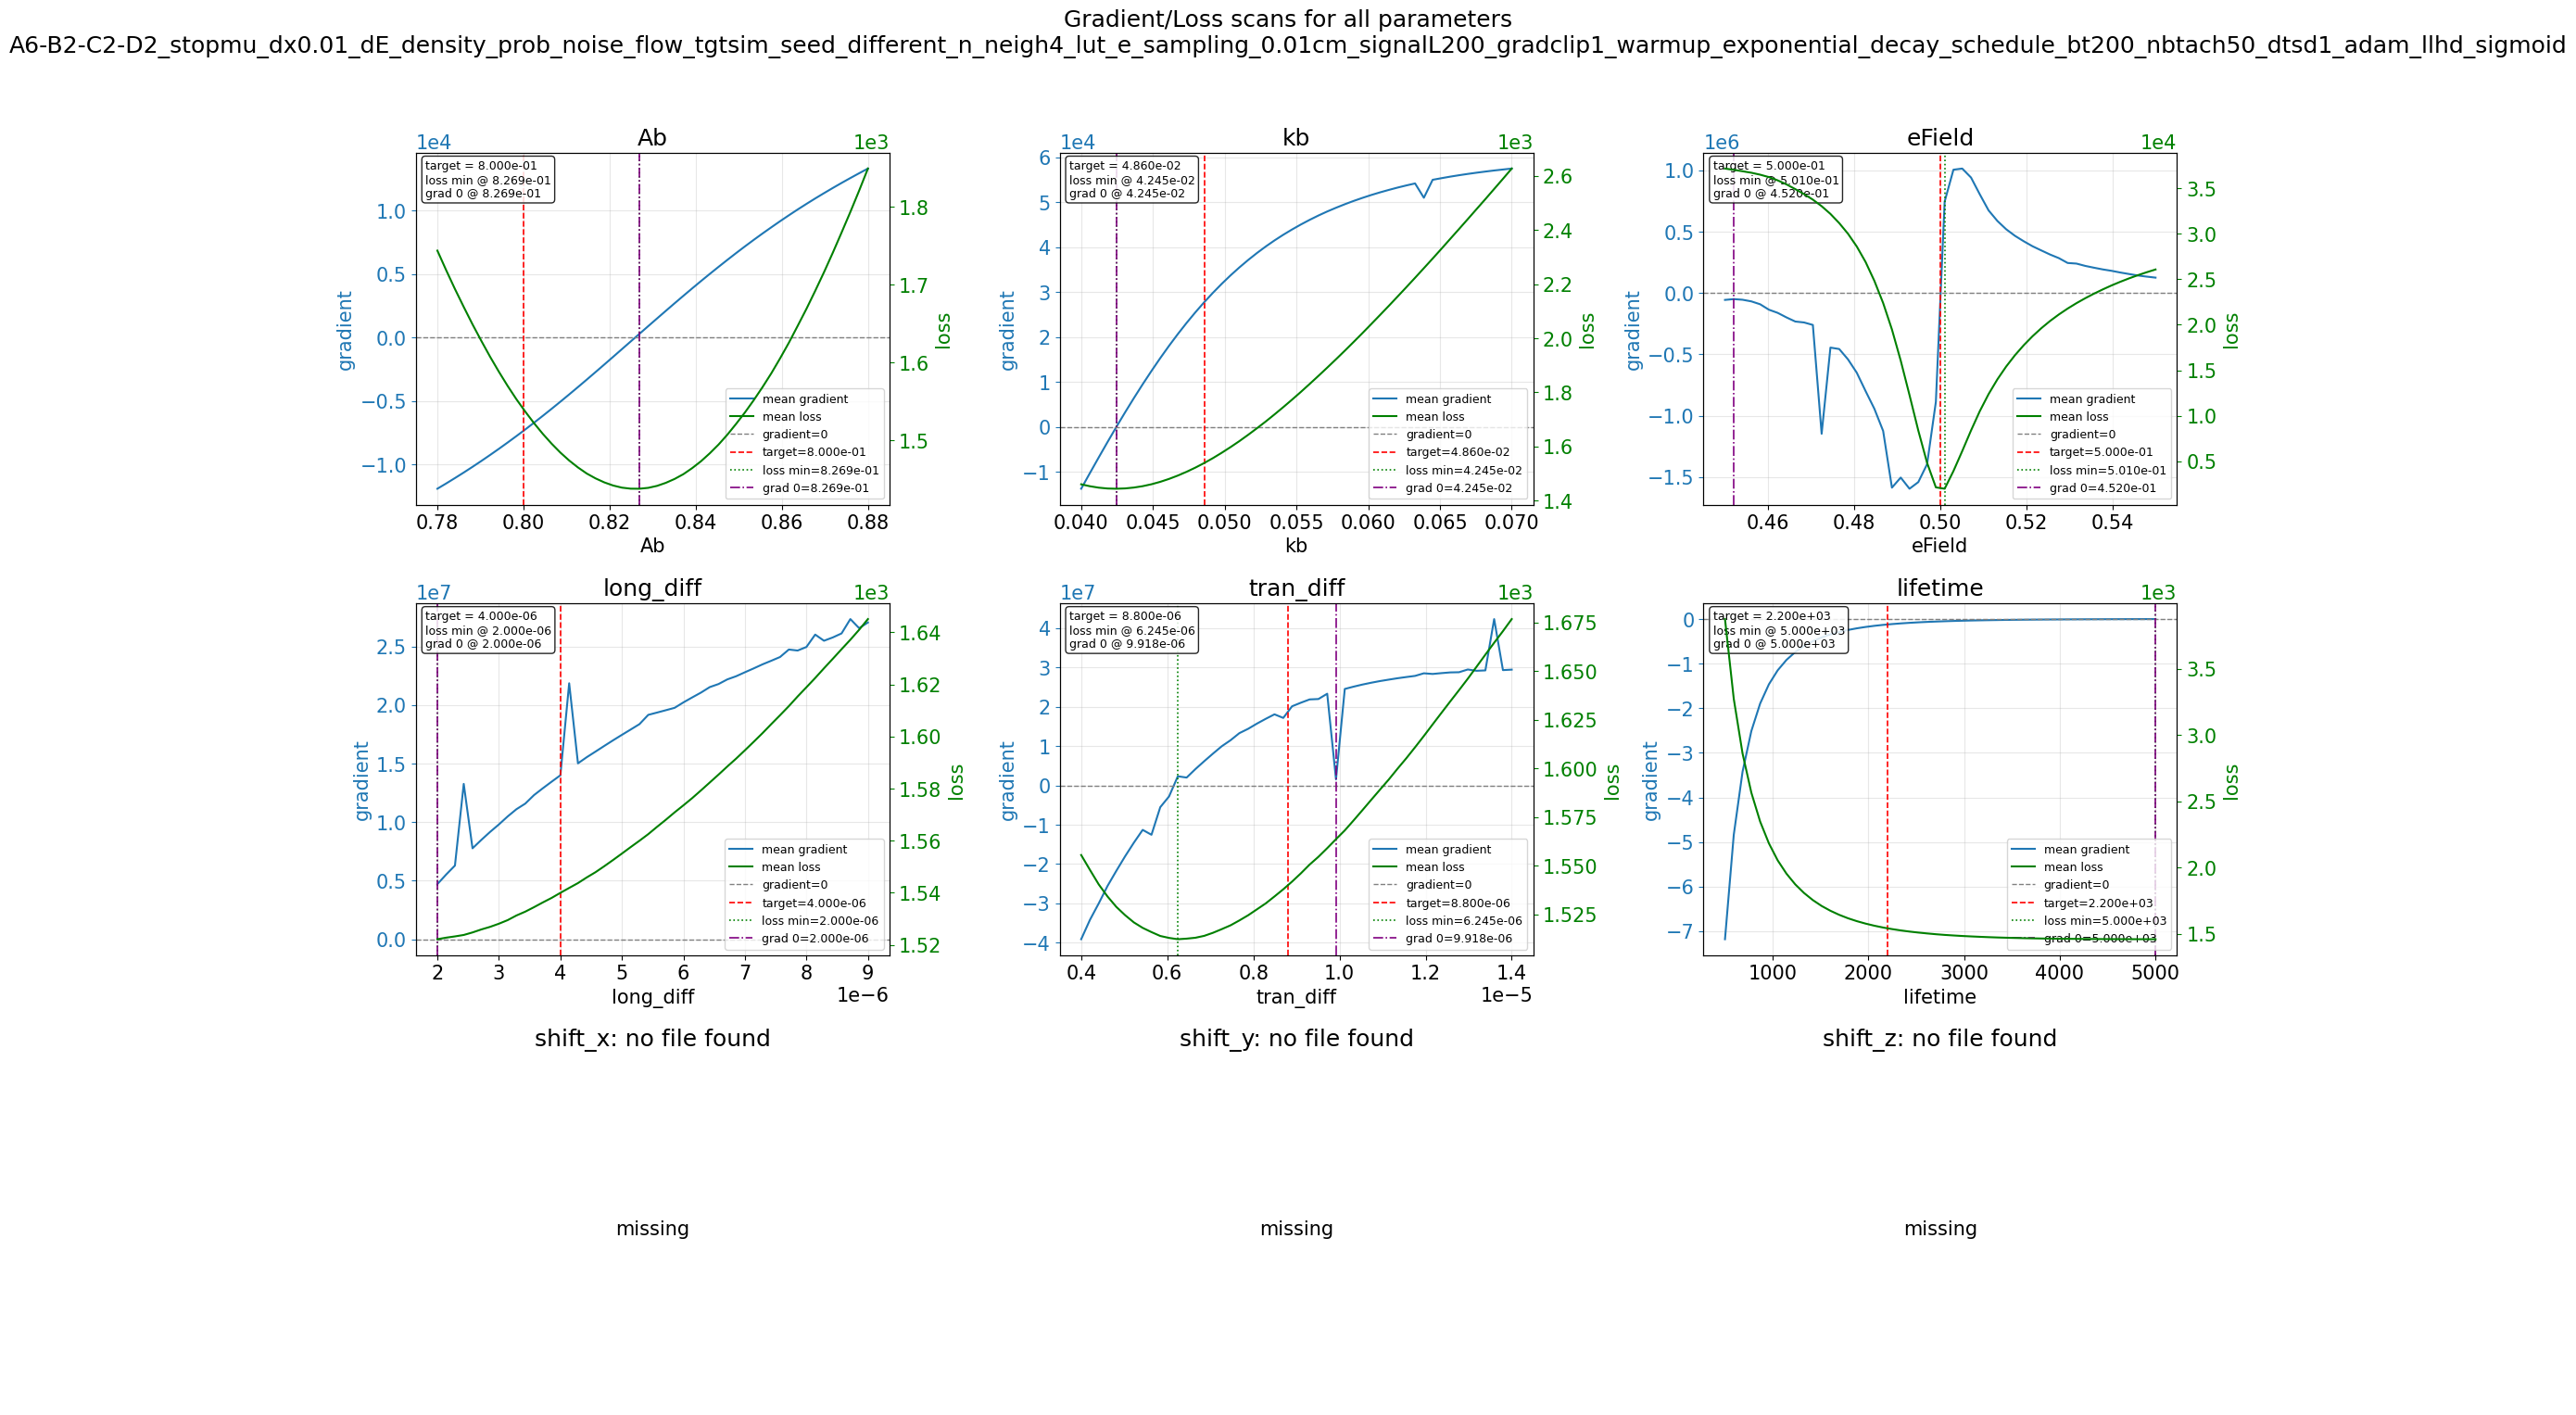

In [10]:
# params = ["Ab", "kb", "eField", "long_diff", "tran_diff", "lifetime"]
# params = ["shift_x", "shift_y", "shift_z"]
params = ["Ab", "kb", "eField", "long_diff", "tran_diff", "lifetime", "shift_x", "shift_y", "shift_z"]

f_dir = "/sdf/group/neutrino/cyifan/diff_sim_playground/larndsim_dEdx_dist/"
tag = "A6-B2-C2-D2_stopmu_dx0.01_dE_density_prob_noise_flow_tgtsim_seed_different_n_neigh4_lut_e_sampling_0.01cm_signalL200_gradclip1_warmup_exponential_decay_schedule_bt200_nbtach50_dtsd1_adam_llhd_sigmoid"
# tag = "stopp_fit_pos_shifted_trk1_dx0.1mm_n_neigh4__signalL400__bt200_nbtach_dtsd1_Adam_llhd_pos_lr_eps1e-10_w3dg0.01_gssg_0.1cm_gsr_0.2cm_medx60_medz30_glbx20_glbz10"
# tag = "stopp_fit_pos_shifted_trk1_dx0.1mm_n_neigh4__signalL400__bt200_nbtach_dtsd1_Adam_llhd_pos_lr_eps1e-10_w3dg0.01_gssg_0.1cm_gsr_0.3cm_medx15_glbx5_glbz5"

n_cols = 3
n_rows = int(np.ceil(len(params) / n_cols))
fig, axs = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 5 * n_rows), squeeze=False)

saved_paths = []
missing_params = []

for i_par, param in enumerate(params):
    ax = axs[i_par // n_cols, i_par % n_cols]
    pattern = os.path.join(f_dir, f"fit_result/scan/history_{param}_batch*_{param}_{tag}*pkl")
    matches = sorted(glob.glob(pattern))
    print(tag)
    print(pattern)
    print(param)
    print(matches)

    if not matches:
        missing_params.append(param)
        ax.set_title(f"{param}: no file found")
        ax.text(0.5, 0.5, "missing", ha="center", va="center", transform=ax.transAxes)
        ax.axis("off")
        continue

    fname = matches[0]
    with open(fname, 'rb') as f:
        results = pickle.load(f)

    param_value = np.sort(np.unique(results[f"{param}_iter"][1:]))
    nbatches = np.count_nonzero(np.asarray(results[f"{param}_iter"]) == param_value[0])
    max_index = (len(results["losses_iter"]) // nbatches) * nbatches

    grad = np.array(results[f"{param}_grad"][:max_index]).reshape(nbatches, -1).T
    loss = np.array(results["losses_iter"][:max_index]).reshape(nbatches, -1).T

    grad_mean = np.nanmean(grad, axis=1)
    loss_mean = np.nanmean(loss, axis=1)

    target = float(results[f"{param}_target"][0])
    loss_min_idx = int(np.nanargmin(loss_mean))
    grad_zero_idx = int(np.nanargmin(np.abs(grad_mean)))

    v_loss_min = float(param_value[loss_min_idx])
    v_grad_zero = float(param_value[grad_zero_idx])
    min_loss_val = float(loss_mean[loss_min_idx])

    l1 = ax.plot(param_value, grad_mean, color='C0', label='mean gradient')
    hline = ax.axhline(0.0, color='gray', linestyle='--', linewidth=1.0, label='gradient=0')
    vline_target = ax.axvline(target, color='red', linestyle='--', linewidth=1.2, label=f'target={target:.3e}')
    vline_loss_min = ax.axvline(v_loss_min, color='green', linestyle=':', linewidth=1.2, label=f'loss min={v_loss_min:.3e}')
    vline_grad_zero = ax.axvline(v_grad_zero, color='purple', linestyle='-.', linewidth=1.2, label=f'grad 0={v_grad_zero:.3e}')
    ax.set_xlabel(param)
    ax.set_ylabel('gradient', color='C0')
    ax.tick_params(axis='y', colors='C0')
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
    ax.grid(alpha=0.3)

    ax2 = ax.twinx()
    l2 = ax2.plot(param_value, loss_mean, color='green', label='mean loss')
    ax2.set_ylabel('loss', color='green')
    ax2.tick_params(axis='y', colors='green')
    ax2.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

    annotation = (
        f"target = {target:.3e}\n"
        f"loss min @ {v_loss_min:.3e}\n"
        f"grad 0 @ {v_grad_zero:.3e}"
    )
    ax.text(
        0.02,
        0.98,
        annotation,
        transform=ax.transAxes,
        va='top',
        ha='left',
        fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85),
    )

    lines = l1 + l2 + [hline, vline_target, vline_loss_min, vline_grad_zero]
    labels = [line.get_label() for line in lines]
    ax.legend(lines, labels, loc='lower right', fontsize=9)
    ax.set_title(param)
    saved_paths.append(fname)

for i_ax in range(len(params), n_rows * n_cols):
    axs[i_ax // n_cols, i_ax % n_cols].axis('off')

fig.suptitle(f"Gradient/Loss scans for all parameters\n{tag}", y=1.02)
fig.tight_layout()
output_path = os.path.join(f_dir, f"plots/all_params_gradient_scan_{tag}.png")
fig.savefig(output_path, bbox_inches='tight')
print(f"Saved combined plot to {output_path}")
if missing_params:
    print(f"Missing parameters: {missing_params}")

Using history sources:
  shift_x: loaded from /sdf/group/neutrino/cyifan/diff_sim_playground/larndsim_fit_dE/fit_result/scan/history_shift_x_batch0_stopp_fit_pos_shifted_trk1_dx0.1mm_hbd_n_neigh4__signalL400__bt200_nbtach_dtsd1_Adam_llhd_lr_eps1e-10_w3dg0.01_gssg_0.1cm_gsr_0.2cm_medx60_medz30_glbx20_glbz10_weights2_.pkl (pattern: /sdf/group/neutrino/cyifan/diff_sim_playground/larndsim_fit_dE/fit_result/scan/history_shift_x_batch*_stopp_fit_pos_shifted_trk1_dx0.1mm_hbd_n_neigh4__signalL400__bt200_nbtach_dtsd1_Adam_llhd_lr_eps1e-10_w3dg0.01_gssg_0.1cm_gsr_0.2cm_medx60_medz30_glbx20_glbz10_weights2*pkl)
  shift_y: loaded from /sdf/group/neutrino/cyifan/diff_sim_playground/larndsim_fit_dE/fit_result/scan/history_shift_y_batch0_stopp_fit_pos_shifted_trk1_dx0.1mm_hbd_n_neigh4__signalL400__bt200_nbtach_dtsd1_Adam_llhd_lr_eps1e-10_w3dg0.01_gssg_0.1cm_gsr_0.2cm_medx60_medz30_glbx20_glbz10_weights2_.pkl (pattern: /sdf/group/neutrino/cyifan/diff_sim_playground/larndsim_fit_dE/fit_result/scan/hist

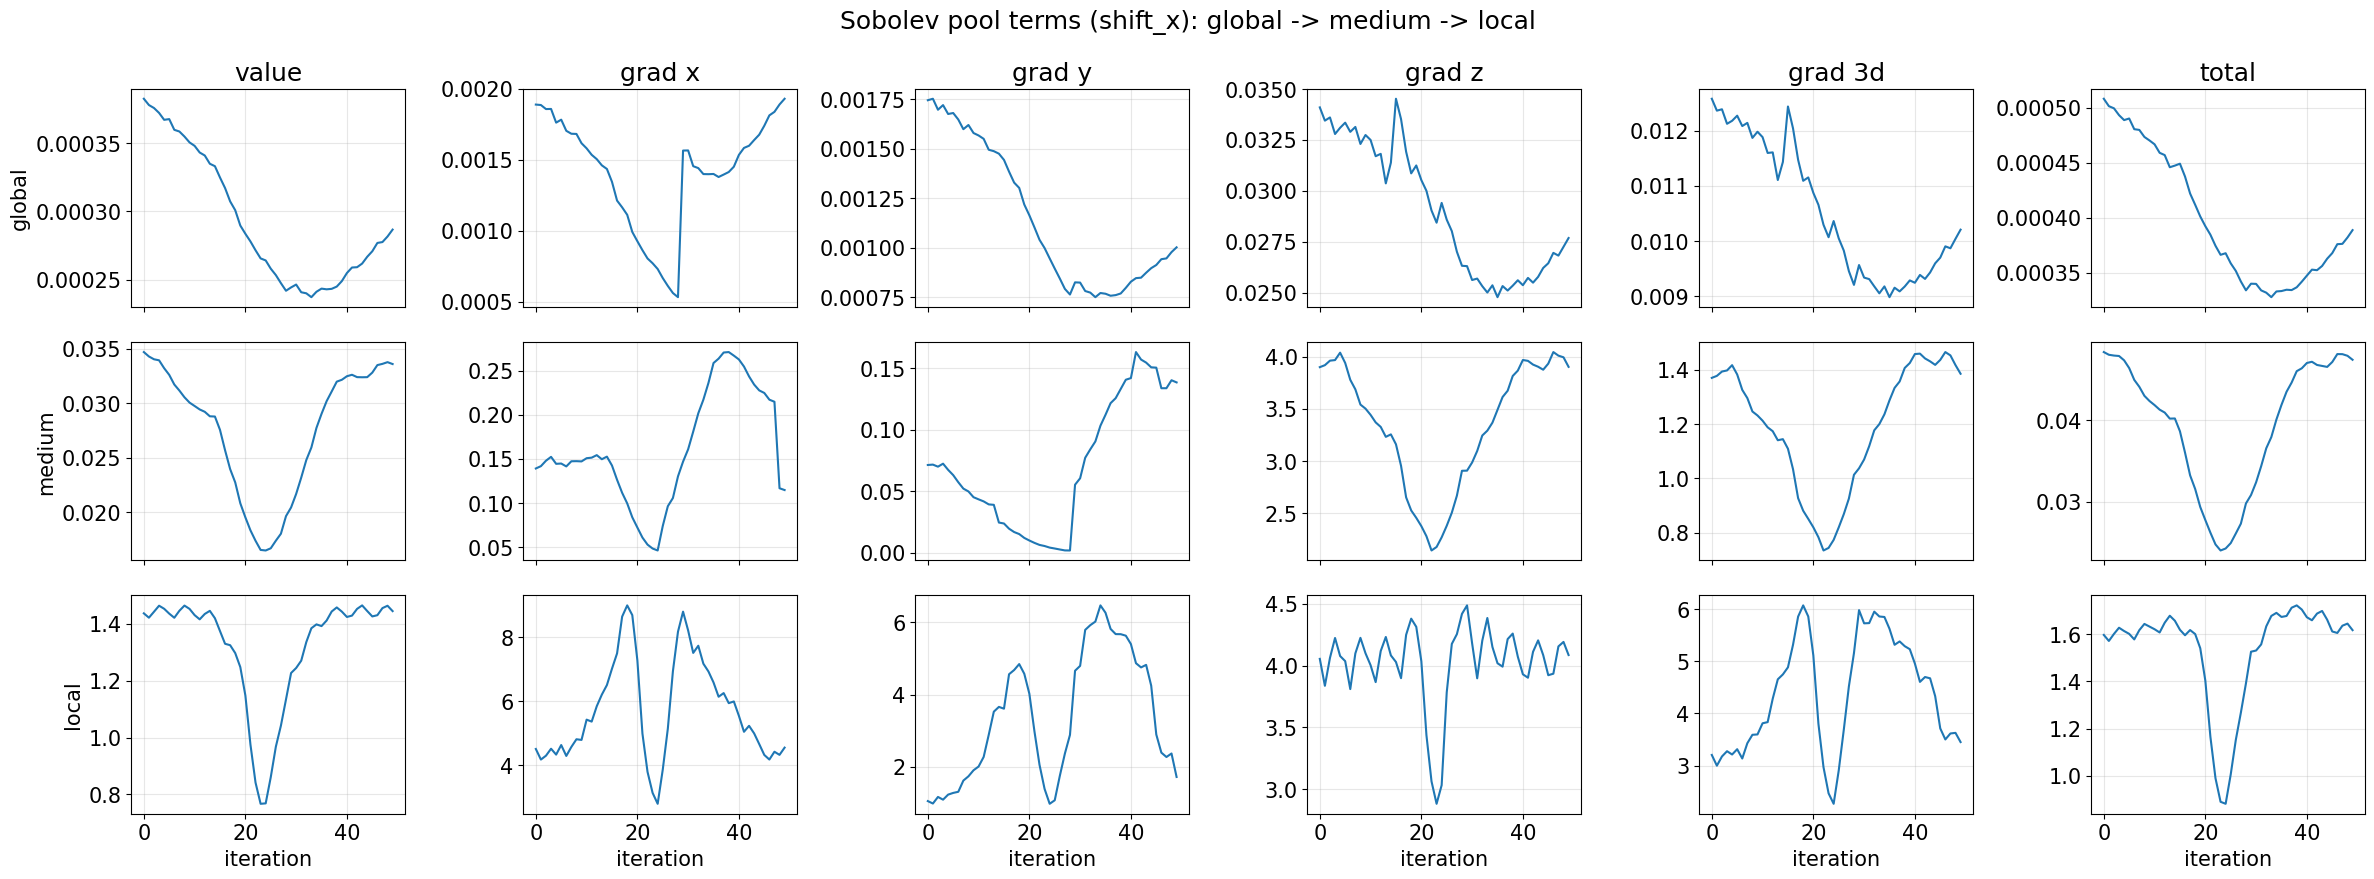

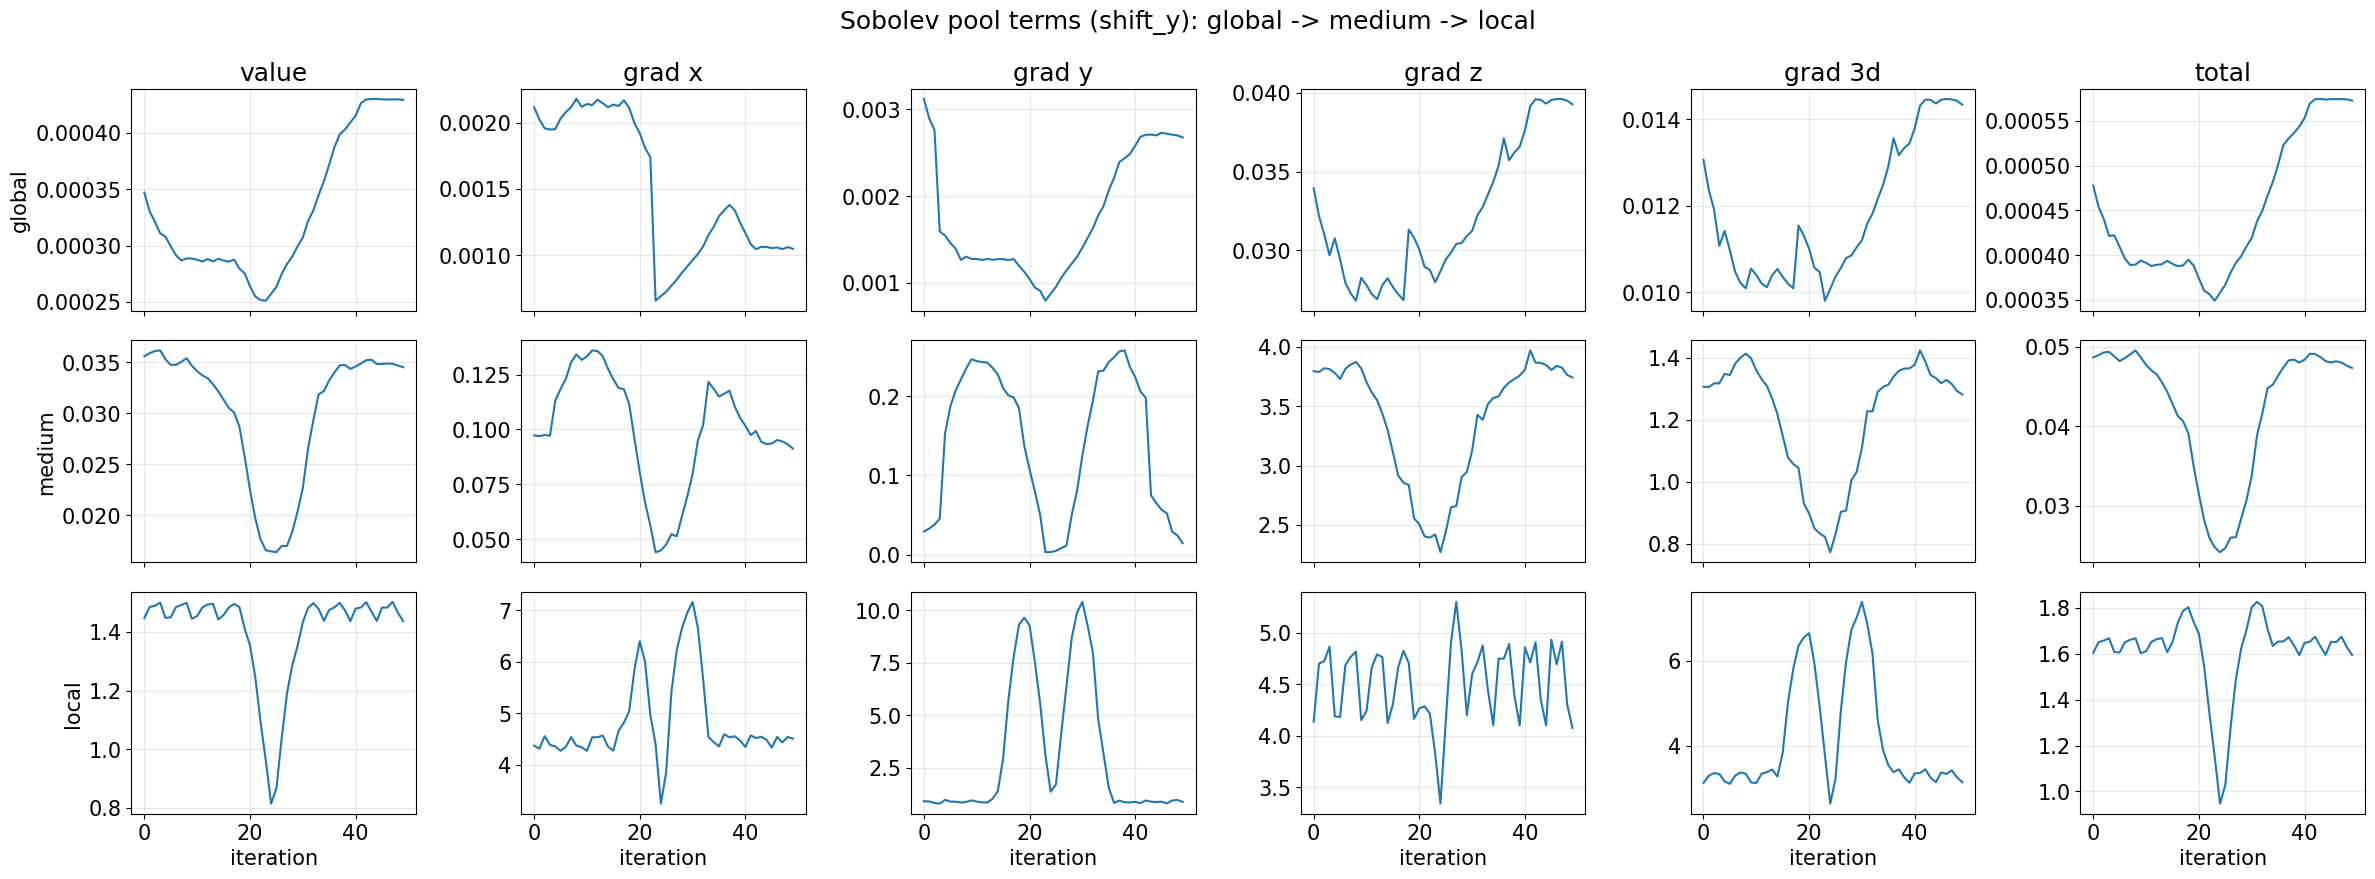

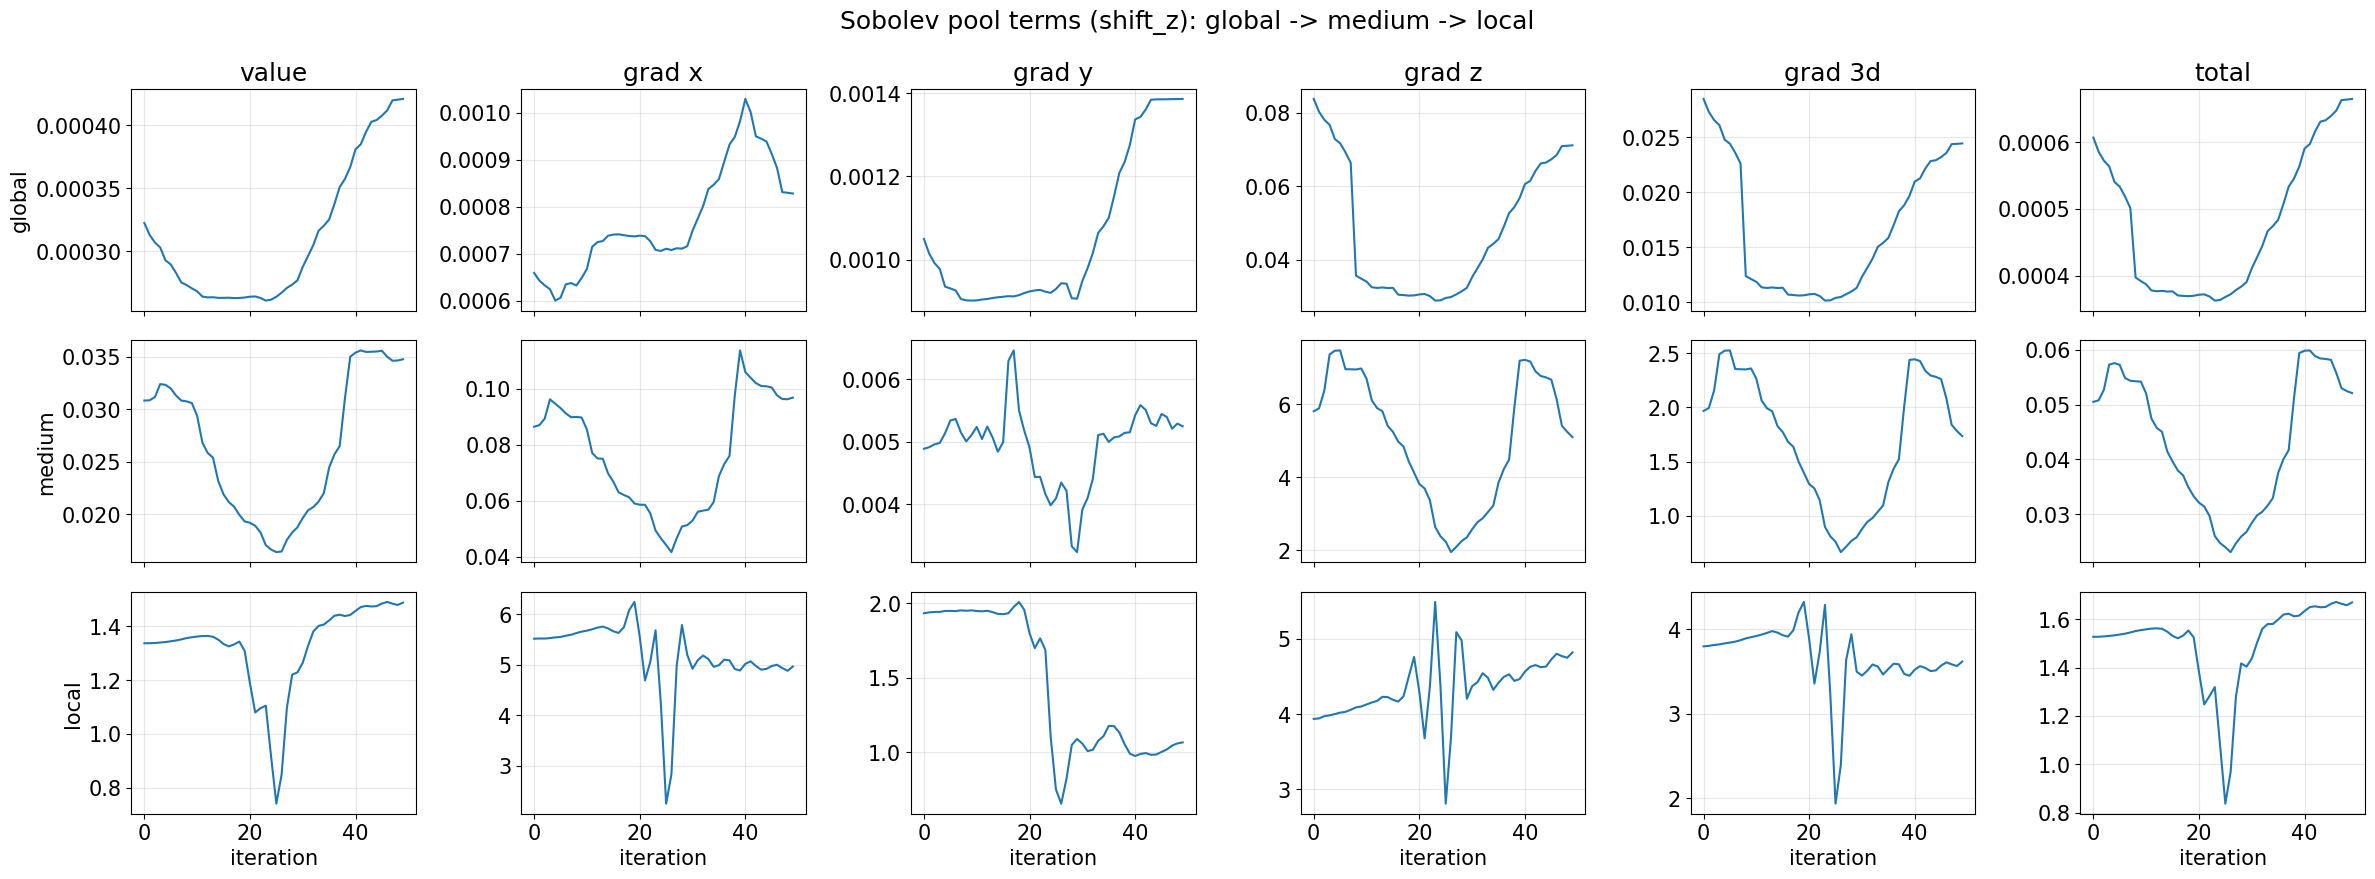

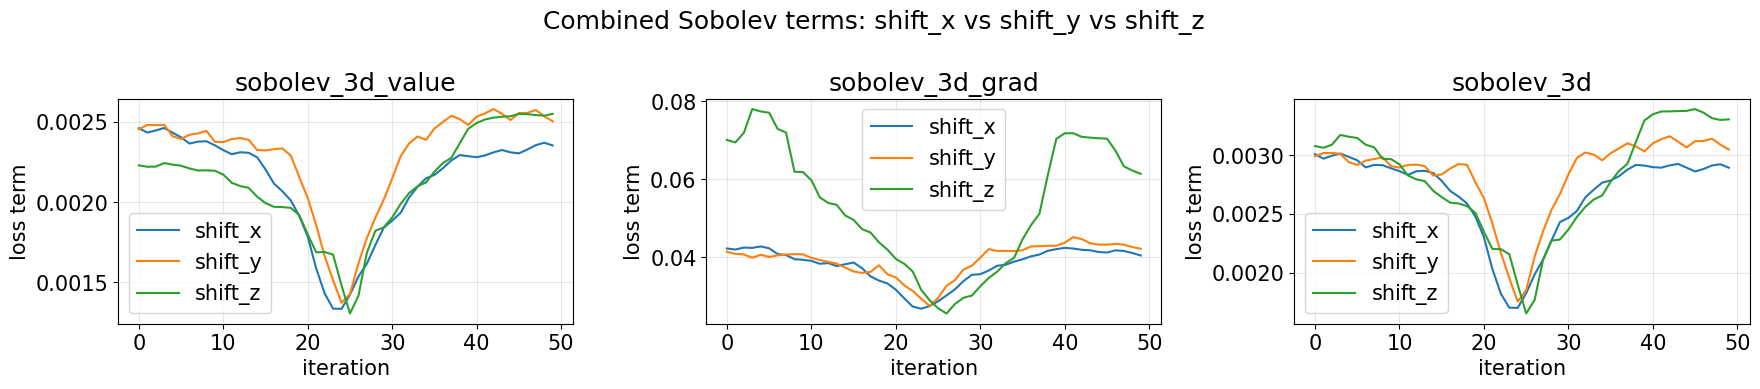

In [ ]:
# Sobolev term scan for shift_x / shift_y / shift_z: global -> medium -> local, and value -> gradients -> total.
# Robust IO: if f_dir/tag are available, load each shift history; otherwise fall back to existing history/results/pkl_file/fname.
def _resolve_history_obj():
    if 'history' in globals() and isinstance(history, dict) and 'aux_iter' in history:
        return history, 'history (existing variable)'

    if 'results' in globals() and isinstance(results, dict) and 'aux_iter' in results:
        return results, 'results (existing variable)'

    candidate_paths = []
    if 'pkl_file' in globals() and isinstance(pkl_file, str):
        candidate_paths.append(pkl_file)

    if 'fname' in globals():
        if isinstance(fname, str):
            if any(ch in fname for ch in ['*', '?', '[']):
                matches = sorted(glob.glob(fname))
                if matches:
                    candidate_paths.append(matches[-1])
            else:
                candidate_paths.append(fname)
        elif isinstance(fname, (list, tuple)) and len(fname) > 0 and isinstance(fname[0], str):
            candidate_paths.append(fname[0])

    for path in candidate_paths:
        if not path:
            continue
        if not os.path.exists(path):
            continue
        with open(path, 'rb') as f:
            obj = pickle.load(f)
        if isinstance(obj, dict) and 'aux_iter' in obj:
            return obj, f'loaded from {path}'

    raise RuntimeError(
        'Could not resolve history object with aux_iter. '
        'Define history/results first or set fname/pkl_file to a valid history .pkl.'
    )


def _find_history_path_for_param(param):
    patterns = []

    if 'f_dir' in globals() and isinstance(f_dir, str) and 'tag' in globals() and isinstance(tag, str):
        patterns.append(os.path.join(f_dir, f'fit_result/scan/history_{param}_batch*_{tag}*pkl'))

    if 'tag' in globals() and isinstance(tag, str):
        patterns.append(f'fit_result/scan/history_{param}_batch*_{tag}*pkl')

    patterns.append(f'fit_result/scan/history_{param}_batch*.pkl')

    for pat in patterns:
        matches = sorted(glob.glob(pat))
        if matches:
            return matches[-1], pat

    return None, None


def _load_shift_histories(params=('shift_x', 'shift_y', 'shift_z')):
    loaded = {}
    sources = {}
    for p in params:
        path, used_pattern = _find_history_path_for_param(p)
        if path is None:
            continue
        with open(path, 'rb') as f:
            obj = pickle.load(f)
        if isinstance(obj, dict) and 'aux_iter' in obj:
            loaded[p] = obj
            sources[p] = f'loaded from {path} (pattern: {used_pattern})'
    return loaded, sources


def _aux_series(history_obj, key, default=np.nan):
    vals = []
    for aux in history_obj.get('aux_iter', []):
        if aux is None:
            vals.append(default)
        else:
            vals.append(aux.get(key, default))
    return np.asarray(vals, dtype=float)


histories, history_sources = _load_shift_histories(params=('shift_x', 'shift_y', 'shift_z'))

if len(histories) == 0:
    history_obj, history_src = _resolve_history_obj()
    histories = {'current': history_obj}
    history_sources = {'current': history_src}

print('Using history sources:')
for p in histories:
    print(f'  {p}: {history_sources.get(p, "unknown")}')

layers = ['global', 'medium', 'local']
terms = [
    ('value', 'value'),
    ('grad_x_e', 'grad x'),
    ('grad_y_e', 'grad y'),
    ('grad_z_e', 'grad z'),
    ('sobolev_3d_grad', 'grad 3d'),
    ('total', 'total'),
]

# Detailed panel per parameter.
for p, history_obj in histories.items():
    nrows = len(layers)
    ncols = len(terms)
    fig, axs = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), sharex=True)

    missing = []
    for i, layer in enumerate(layers):
        for j, (suffix, term_label) in enumerate(terms):
            key = f'sobolev_pool_{layer}_{suffix}'
            y = _aux_series(history_obj, key)
            ax = axs[i, j] if nrows > 1 else axs[j]

            if np.all(np.isnan(y)):
                missing.append(key)
                ax.text(0.5, 0.5, 'missing', ha='center', va='center', transform=ax.transAxes)
            else:
                ax.plot(y, lw=1.5)
                ax.grid(alpha=0.3)

            if i == 0:
                ax.set_title(term_label)
            if j == 0:
                ax.set_ylabel(layer)
            if i == nrows - 1:
                ax.set_xlabel('iteration')

    fig.suptitle(f'Sobolev pool terms ({p}): global -> medium -> local')
    fig.tight_layout()
    fig.savefig(f_dir + f'plots/sobolev_terms_comparison_{p}_hbd.png')

    if missing:
        print(f'Missing aux keys for {p}:')
        for k in missing:
            print('  ', k)

# Comparison summary across shift_x / shift_y / shift_z (or available histories).
summary_keys = ['sobolev_3d_value', 'sobolev_3d_grad', 'sobolev_3d']
fig2, axs2 = plt.subplots(1, len(summary_keys), figsize=(6 * len(summary_keys), 4), sharex=True)

if len(summary_keys) == 1:
    axs2 = [axs2]

for idx, k in enumerate(summary_keys):
    ax2 = axs2[idx]
    has_any = False
    for p, history_obj in histories.items():
        y = _aux_series(history_obj, k)
        if not np.all(np.isnan(y)):
            ax2.plot(y, label=p, lw=1.5)
            has_any = True
    ax2.grid(alpha=0.3)
    ax2.set_xlabel('iteration')
    ax2.set_ylabel('loss term')
    ax2.set_title(k)
    if has_any:
        ax2.legend()
    else:
        ax2.text(0.5, 0.5, 'missing', ha='center', va='center', transform=ax2.transAxes)

fig2.suptitle('Combined Sobolev terms: shift_x vs shift_y vs shift_z')
fig2.tight_layout()
fig2.savefig(f_dir + f'plots/sobolev_terms_comparison_hbd.png')

In [ ]:
history.keys()

NameError: name 'history' is not defined

Text(0, 0.5, 'loss time term')

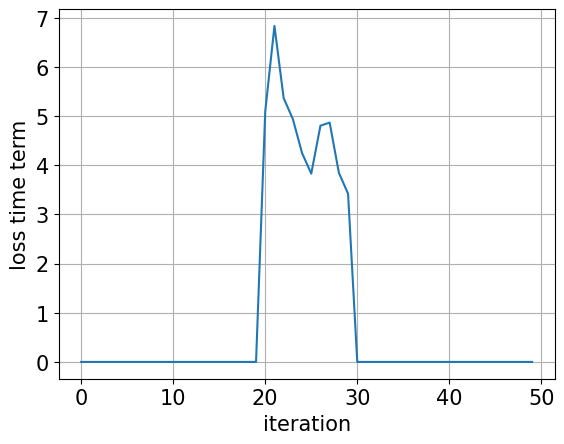

In [ ]:
plt.plot(log_likelihood_tick)
plt.grid()
plt.xlabel("iteration")
plt.ylabel("loss time term")

In [ ]:
fname=glob.glob(f'fit_result/scan/history_eField_batch2_eField_proton_1E5_edep_closure_target_nom_probablistic_n_neigh_4_bt400_dtsd1_mse_adc_1b1e9dba-7f1e-4b9b-a5cd-e8899fbea92c.pkl')[0]

In [ ]:
with open(fname, 'rb') as f:
    results = pickle.load(f)

In [ ]:
results.keys()

dict_keys(['eField', 'eField_target', 'eField_init', 'size_history', 'memory', 'config', 'eField_grad', 'eField_iter', 'step_time', 'losses_iter'])

In [ ]:
results['losses_iter'], results['eField_grad'], results['eField_iter']

([0.035560671240091324,
  0.0,
  0.033408671617507935,
  0.034917958080768585,
  1.078959303413285e-05,
  0.03287650644779205,
  0.03602480888366699,
  1.52587890625e-05,
  0.03379720449447632],
 [-0.2780310809612274,
  nan,
  0.259601354598999,
  -0.2644885182380676,
  -0.00015940552111715078,
  0.2507450580596924,
  -0.27081581950187683,
  0.0003794203221332282,
  0.252263605594635],
 [0.5, 0.45, 0.5, 0.55, 0.45, 0.5, 0.55, 0.45, 0.5, 0.55])

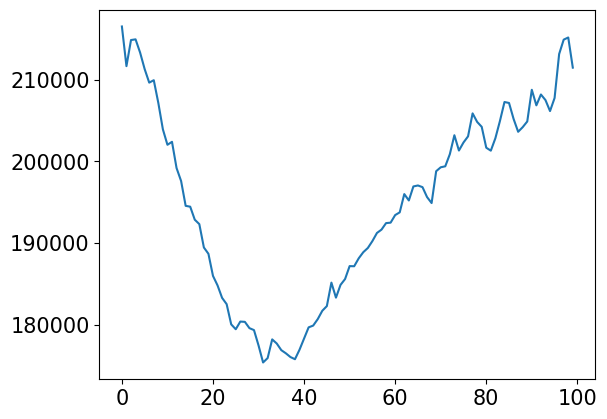

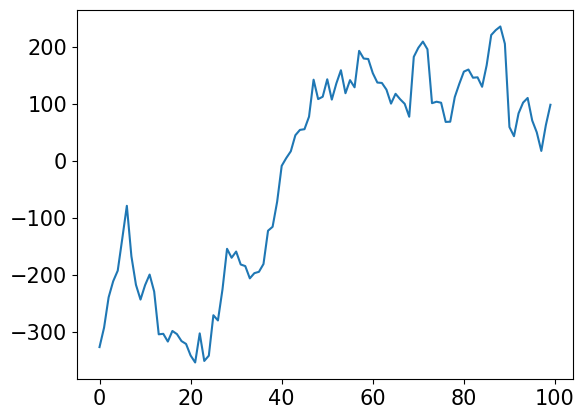

In [ ]:
plt.plot(results['losses_iter'][300:400])
plt.show()
plt.plot(results['shift_z_grad'][300:400])

In [ ]:
data = np.load("investigate.npz")

In [ ]:
np.where(data['ticks']==-999)

(array([], dtype=int64), array([], dtype=int64))

In [ ]:
param_value = np.sort(np.unique(results[f"{param}_iter"][1:]))
    nbatches = np.count_nonzero(results[f"{param}_iter"] == param_value[0])
    st_nbt = nbatches  

    max_index = (len(results["losses_iter"])//nbatches)*nbatches
    param_value = np.average(np.array(results[f"{param}_iter"][1:max_index + 1]).reshape(-1, nbatches), axis=1)

IndentationError: unexpected indent (1748616064.py, line 2)

In [ ]:
np.sort(np.unique(results[f"Ab_iter"][1:]))

array([0.58      , 0.58251256, 0.58502513, 0.58753769, 0.59005025,
       0.59256281, 0.59507538, 0.59758794, 0.6001005 , 0.60261307,
       0.60512563, 0.60763819, 0.61015075, 0.61266332, 0.61517588,
       0.61768844, 0.62020101, 0.62271357, 0.62522613, 0.62773869,
       0.63025126, 0.63276382, 0.63527638, 0.63778894, 0.64030151,
       0.64281407, 0.64532663, 0.6478392 , 0.65035176, 0.65286432,
       0.65537688, 0.65788945, 0.66040201, 0.66291457, 0.66542714,
       0.6679397 , 0.67045226, 0.67296482, 0.67547739, 0.67798995,
       0.68050251, 0.68301508, 0.68552764, 0.6880402 , 0.69055276,
       0.69306533, 0.69557789, 0.69809045, 0.70060302, 0.70311558,
       0.70562814, 0.7081407 , 0.71065327, 0.71316583, 0.71567839,
       0.71819095, 0.72070352, 0.72321608, 0.72572864, 0.72824121,
       0.73075377, 0.73326633, 0.73577889, 0.73829146, 0.74080402,
       0.74331658, 0.74582915, 0.74834171, 0.75085427, 0.75336683,
       0.7558794 , 0.75839196, 0.76090452, 0.76341709, 0.76592

In [ ]:
plt.plot(this_grad[1])

NameError: name 'this_grad' is not defined

In [ ]:
with open(f[0], 'rb') as f:
    results = pickle.load(f)

In [ ]:
results.keys()

dict_keys(['Ab', 'Ab_target', 'Ab_init', 'size_history', 'memory', 'config', 'Ab_grad', 'Ab_iter', 'step_time', 'losses_iter'])

In [ ]:
len(results['kb_grad'])

400

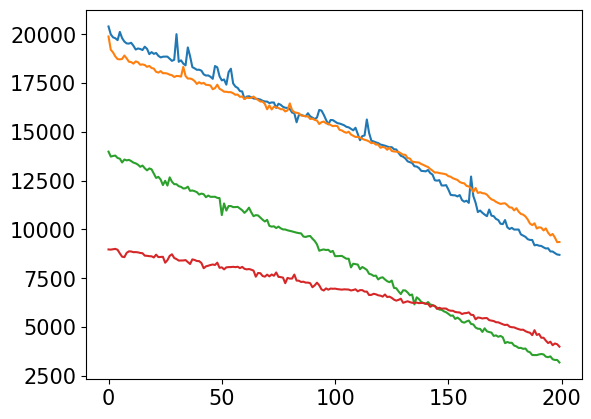

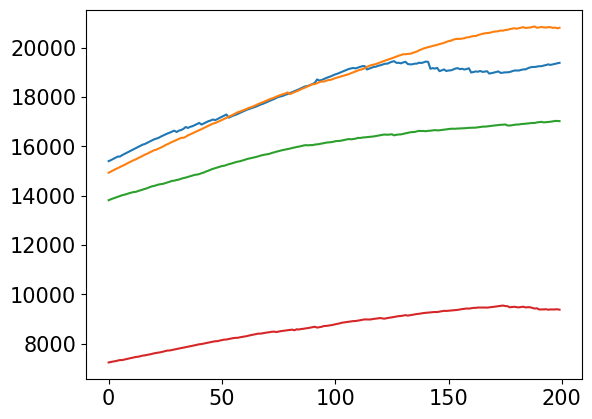

In [ ]:
plt.plot(np.array(results['Ab_grad']).reshape(4, 200).T)
plt.show()
plt.plot(np.array(results['losses_iter']).reshape(4, 200).T)
plt.show()

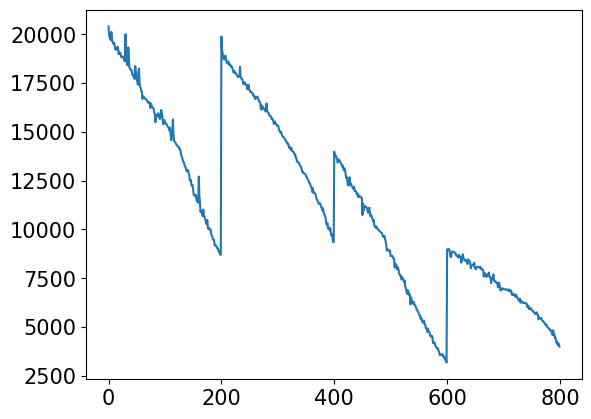

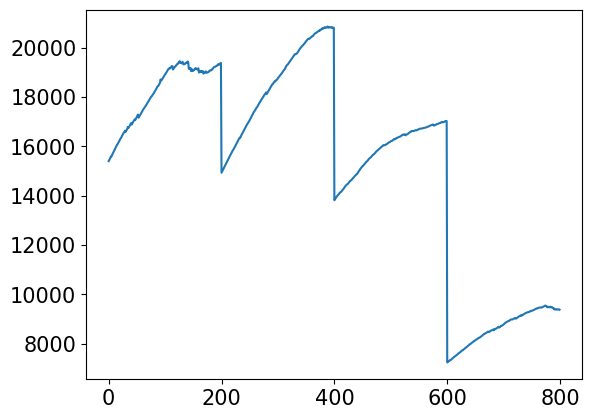

In [ ]:
plt.plot(results['Ab_grad'], "-")
plt.show()
plt.plot(results['losses_iter'])
plt.show()

['fit_result/fit_stability/history_iter5000_Ab_p_1E5_6par_loss_scan_noise_tgt_no_clip_bt2000_tgtsd0_dtsd1_adam_chamfer_3d_6363bd6e-f995-4603-8a98-8b664783c650.pkl']
[6]
[ 6 11 45]
Outlier batch [ 6 11 45]
Remaining number of batches: 47


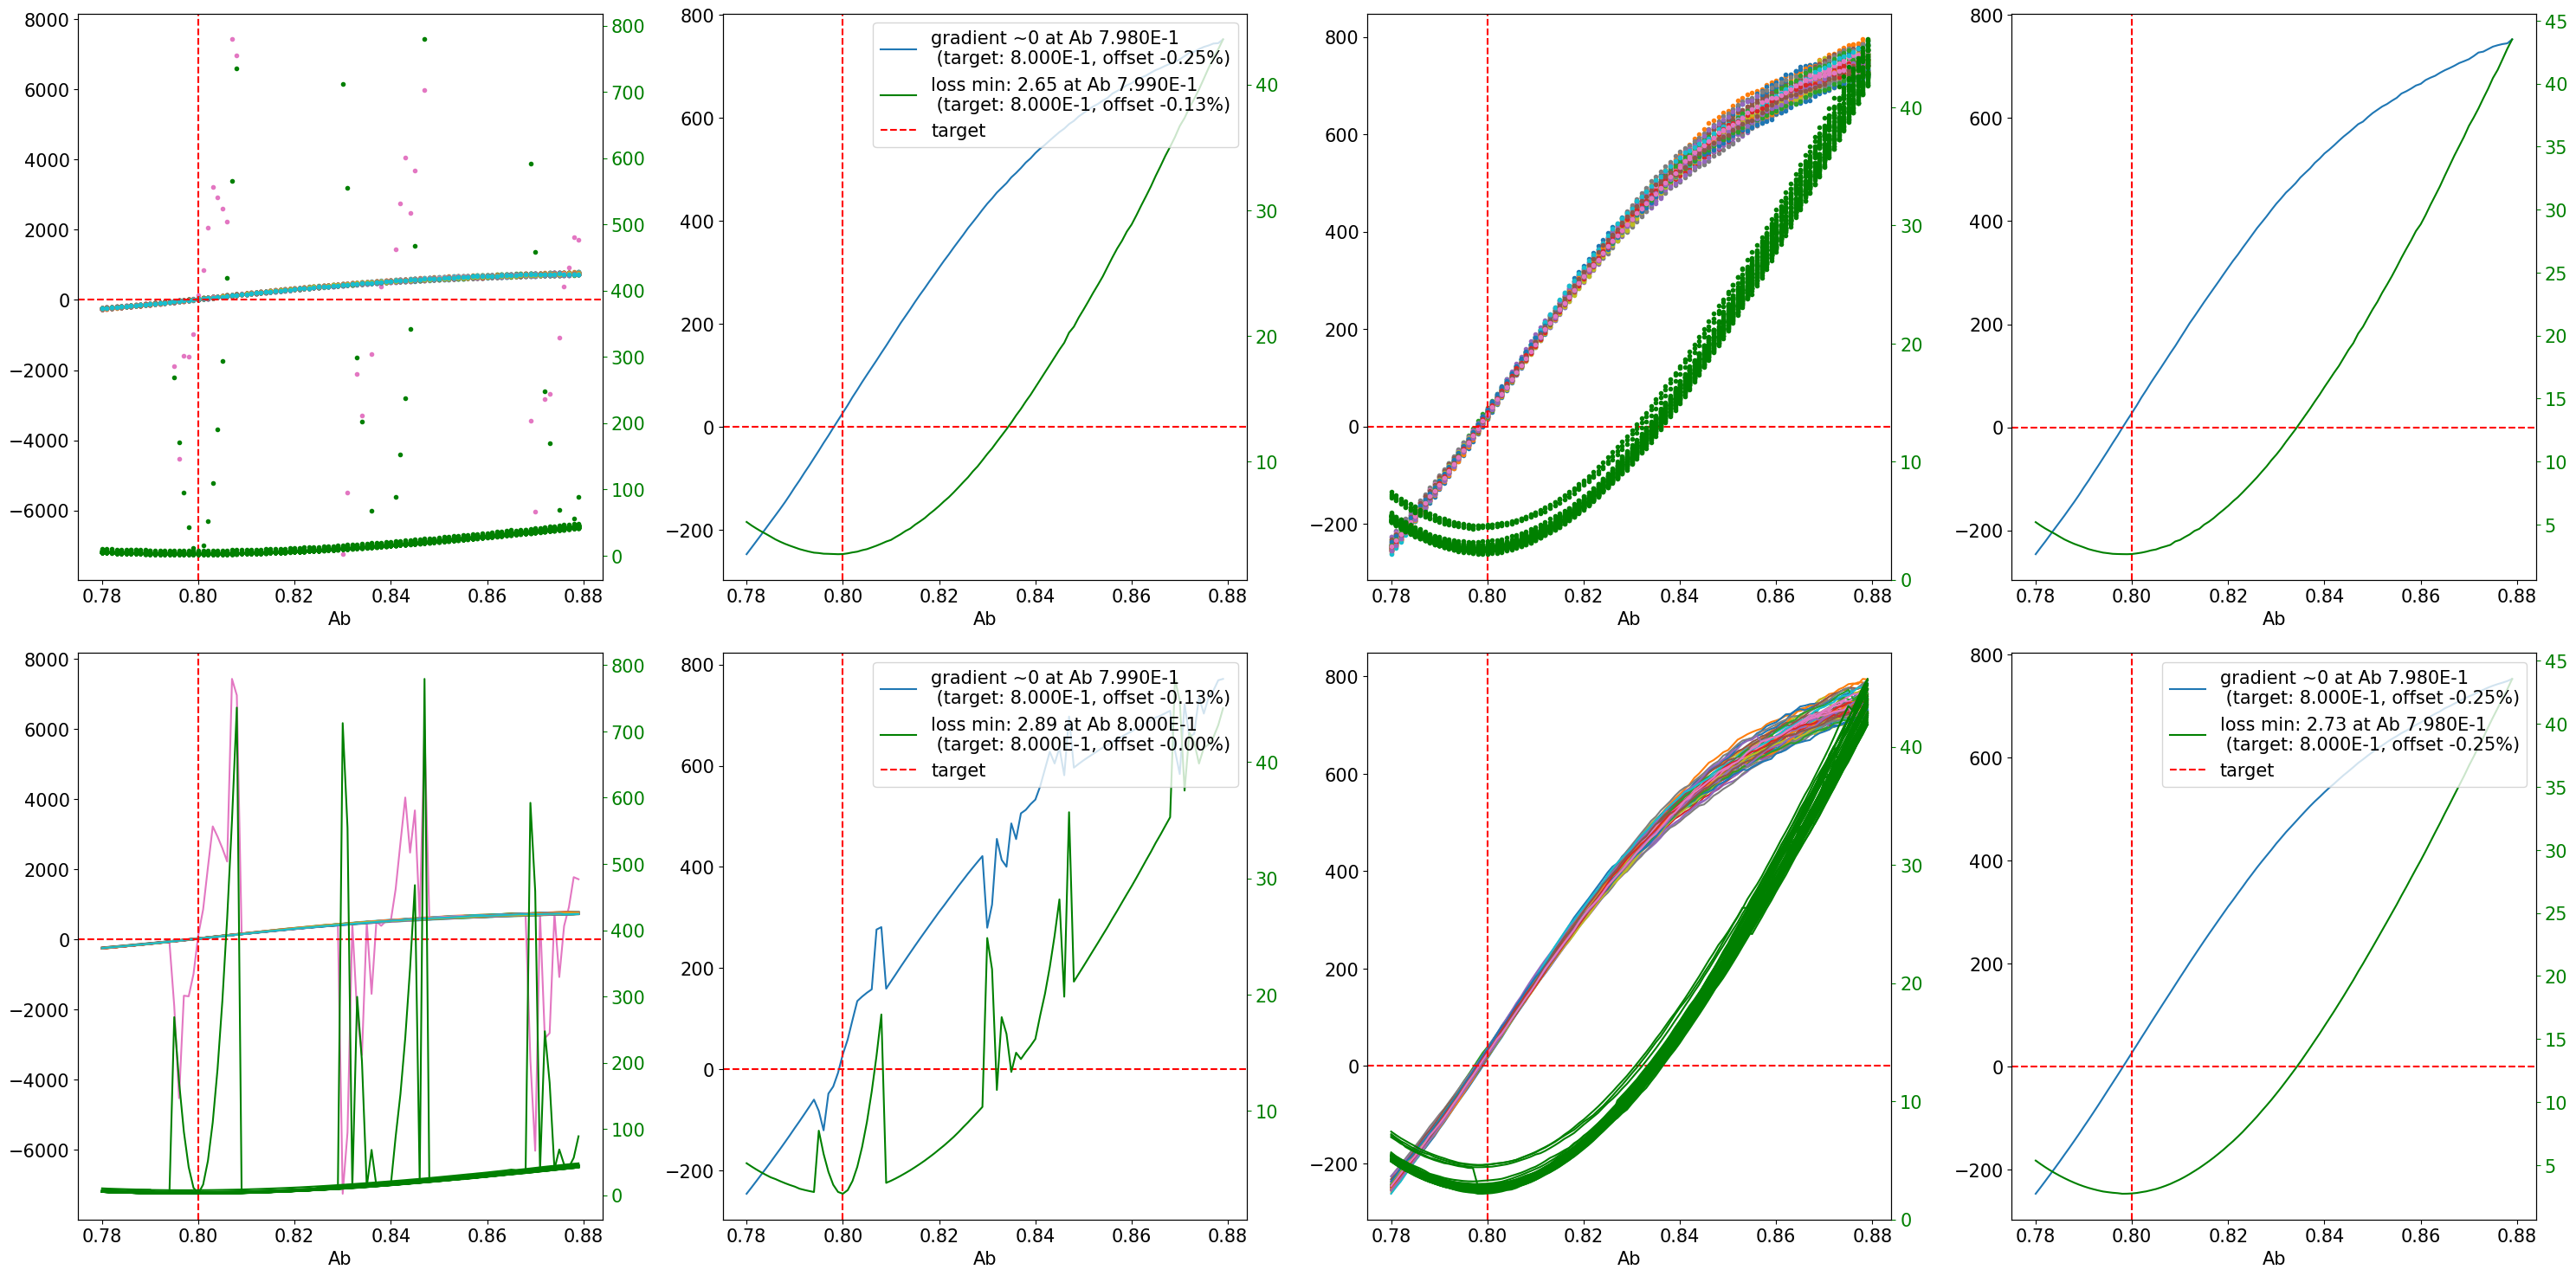

In [ ]:
# Making 8 plots for each scan 
# 0: plot all in dots  | 2: median | 4: cleaned up batches with dots  | 6: clean median
# 1: plot all in lines | 3: mean   | 5: cleaned up batches with lines | 7: clean mean
def plot_gradient_scan(fname, n_std = 3):
    fig, axs = plt.subplots(2, 4, figsize=(30, 15))
    with open(fname, 'rb') as f:
        results = pickle.load(f)    
    # print_config(results['config'])    
    params = [key.replace('_grad', '') for key in results.keys() if '_grad' in key]
    nb_params = len(params)
    assert(nb_params == 1)
    param = params[0]

    target = results[f"{param}_target"]

    global st_bt
    global st_iter
    global st_nbt
    global st_nsp
    global st_lr
    st_bt = vars(results['config'])['max_batch_len']
    st_iter = vars(results['config'])['iterations']    
    st_lr = vars(results['config'])['lr']    

    # nbatches = results['config'].max_nbatch
    
    # max_index = (len(results["losses_iter"])//nbatches)*nbatches

    # param_value = np.average(np.array(results[f"{param}_iter"][1:max_index + 1]).reshape(-1, nbatches), axis=1)
    param_value = np.sort(np.unique(results[f"{param}_iter"][1:]))
    nbatches = np.count_nonzero(results[f"{param}_iter"] == param_value[0])
    st_nbt = nbatches
  

    max_index = (len(results["losses_iter"])//nbatches)*nbatches
    param_value = np.average(np.array(results[f"{param}_iter"][1:max_index + 1]).reshape(-1, nbatches), axis=1)

    grad = np.array(results[f"{param}_grad"][:max_index]).reshape(-1, nbatches)
    loss = np.array(results["losses_iter"][:max_index]).reshape(-1, nbatches)

    grad_median = np.nanmedian(grad, axis=1)
    loss_median = np.nanmedian(loss, axis=1)

    grad_mean = np.nanmean(grad, axis=1)
    loss_mean = np.nanmean(loss, axis=1)

    clean_grad, clean_loss = reject_outliers(grad, loss, n_std)

    clean_grad_median = np.nanmedian(clean_grad, axis=1)
    clean_loss_median = np.nanmedian(clean_loss, axis=1)

    clean_grad_mean = np.nanmean(clean_grad, axis=1)
    clean_loss_mean = np.nanmean(clean_loss, axis=1)

    st_nsp = grad.shape[0]

    for i_plt in range(8):
        loss_min = ""
        gradient0 = ""
        style = "-"
        ax = axs[i_plt%2, i_plt//2]
        if i_plt < 2:
            this_grad = grad
            this_loss = loss
            if i_plt == 0:
                style = "."
        elif i_plt == 2:
            this_grad = grad_median
            this_loss = loss_median
            
        elif i_plt == 3:
            this_grad = grad_mean
            this_loss = loss_mean
        elif i_plt < 6:
            this_grad = clean_grad
            this_loss = clean_loss
            if i_plt == 4:
                style = "."
        elif i_plt == 6:
            this_grad = clean_grad_median
            this_loss = clean_loss_median
        elif i_plt == 7:
            this_grad = clean_grad_mean
            this_loss = clean_loss_mean

        if i_plt in [2,3,6,7]:
            v_target = results[f'{param}_target'][0]
            v_loss_min = param_value[np.argmin(this_loss)]
            off_loss_min = (v_loss_min - v_target) / v_target * 100
            v_gradient0 = param_value[np.argmin(abs(this_grad))]
            off_gradient0 = (v_gradient0 - v_target) / v_target * 100
            loss_min = f" min: {np.min(this_loss):.2f} at {param} {Decimal(v_loss_min):.3E} \n (target: {Decimal(v_target):.3E}, offset {off_loss_min:.2f}%)"
            gradient0 = f" ~0 at {param} {Decimal(v_gradient0):.3E} \n (target: {Decimal(v_target):.3E}, offset {off_gradient0:.2f}%)"
            
        l1 = ax.plot(param_value, this_grad, style, label=f"gradient{gradient0}")
        ax2 = ax.twinx()
        ax2.tick_params(axis='y', colors='green')
    
        l2 = ax2.plot(param_value, this_loss, style, color='green', label=f"loss{loss_min}")
        l3 = ax.axvline(target, color='red', linestyle="--", label='target')
        l4 = ax.axhline(0, color='red', linestyle="--", label='target')
    
        lns = l1 + l2 + [l3]
        labs = [l.get_label() for l in lns]
        if i_plt in [2,3,6,7]:
            ax2.legend(lns, labs, loc="upper right")
            # ax2.legend(lns, labs, loc=0)
        ax.set_xlabel(param)
        # ax.set_xlim([results[f'{param}_target'][0]*0.98, results[f'{param}_target'][0]*1.02])

    plt.tight_layout()

list_of_files = glob.glob('fit_result/fit_stability/*iter5000*Ab*p_1E5*scan_noise_tgt_*bt2000*.pkl')
# params= ["Ab", "kb", "eField", "long", "tran", "lifetime"]
# latest_files = sorted(list_of_files, key=lambda x: params.index(x.split("_")[4]))
# # latest_files = sorted(list_of_files, key=os.path.getctime)[-9:]
print(list_of_files)

plot_gradient_scan(list_of_files[0], n_std = 3)

# ## 1 all dots
# fig, axs = plt.subplots(2, 3, figsize=(20, 15))

# for i, f in enumerate(latest_files):
#     ax = axs[i//3, i%3]
#     plot_gradient_scan(f, ax, 1)
# fig.tight_layout()
# # fig.savefig(f"plots/gradient_scan_noise_tgt_p_1E5_bt{st_bt}_iter{st_iter}_nbt{st_nbt}_nsp{st_nsp}_lr{st_lr}_dots.pdf")

# ## 2 all lines
# fig, axs = plt.subplots(2, 3, figsize=(20, 15))

# for i, f in enumerate(latest_files):
#     ax = axs[i//3, i%3]
#     plot_gradient_scan(f, ax, 2)
# fig.tight_layout()
# # fig.savefig(f"plots/gradient_scan_noise_tgt_p_1E5_bt{st_bt}_iter{st_iter}_nbt{st_nbt}_nsp{st_nsp}_lr{st_lr}_lines.pdf")

# ## 3 median
# fig, axs = plt.subplots(2, 3, figsize=(20, 15))

# for i, f in enumerate(latest_files):
#     ax = axs[i//3, i%3]
#     plot_gradient_scan(f, ax, 3)
# fig.tight_layout()
# # fig.savefig(f"plots/gradient_scan_noise_tgt_p_1E5_bt{st_bt}_iter{st_iter}_nbt{st_nbt}_nsp{st_nsp}_lr{st_lr}_median.pdf")

# ## 4 mean
# fig, axs = plt.subplots(2, 3, figsize=(20, 15))

# for i, f in enumerate(latest_files):
#     ax = axs[i//3, i%3]
#     plot_gradient_scan(f, ax, 4)
# fig.tight_layout()
# # fig.savefig(f"plots/gradient_scan_noise_tgt_p_1E5_bt{st_bt}_iter{st_iter}_nbt{st_nbt}_nsp{st_nsp}_lr{st_lr}_mean.pdf")

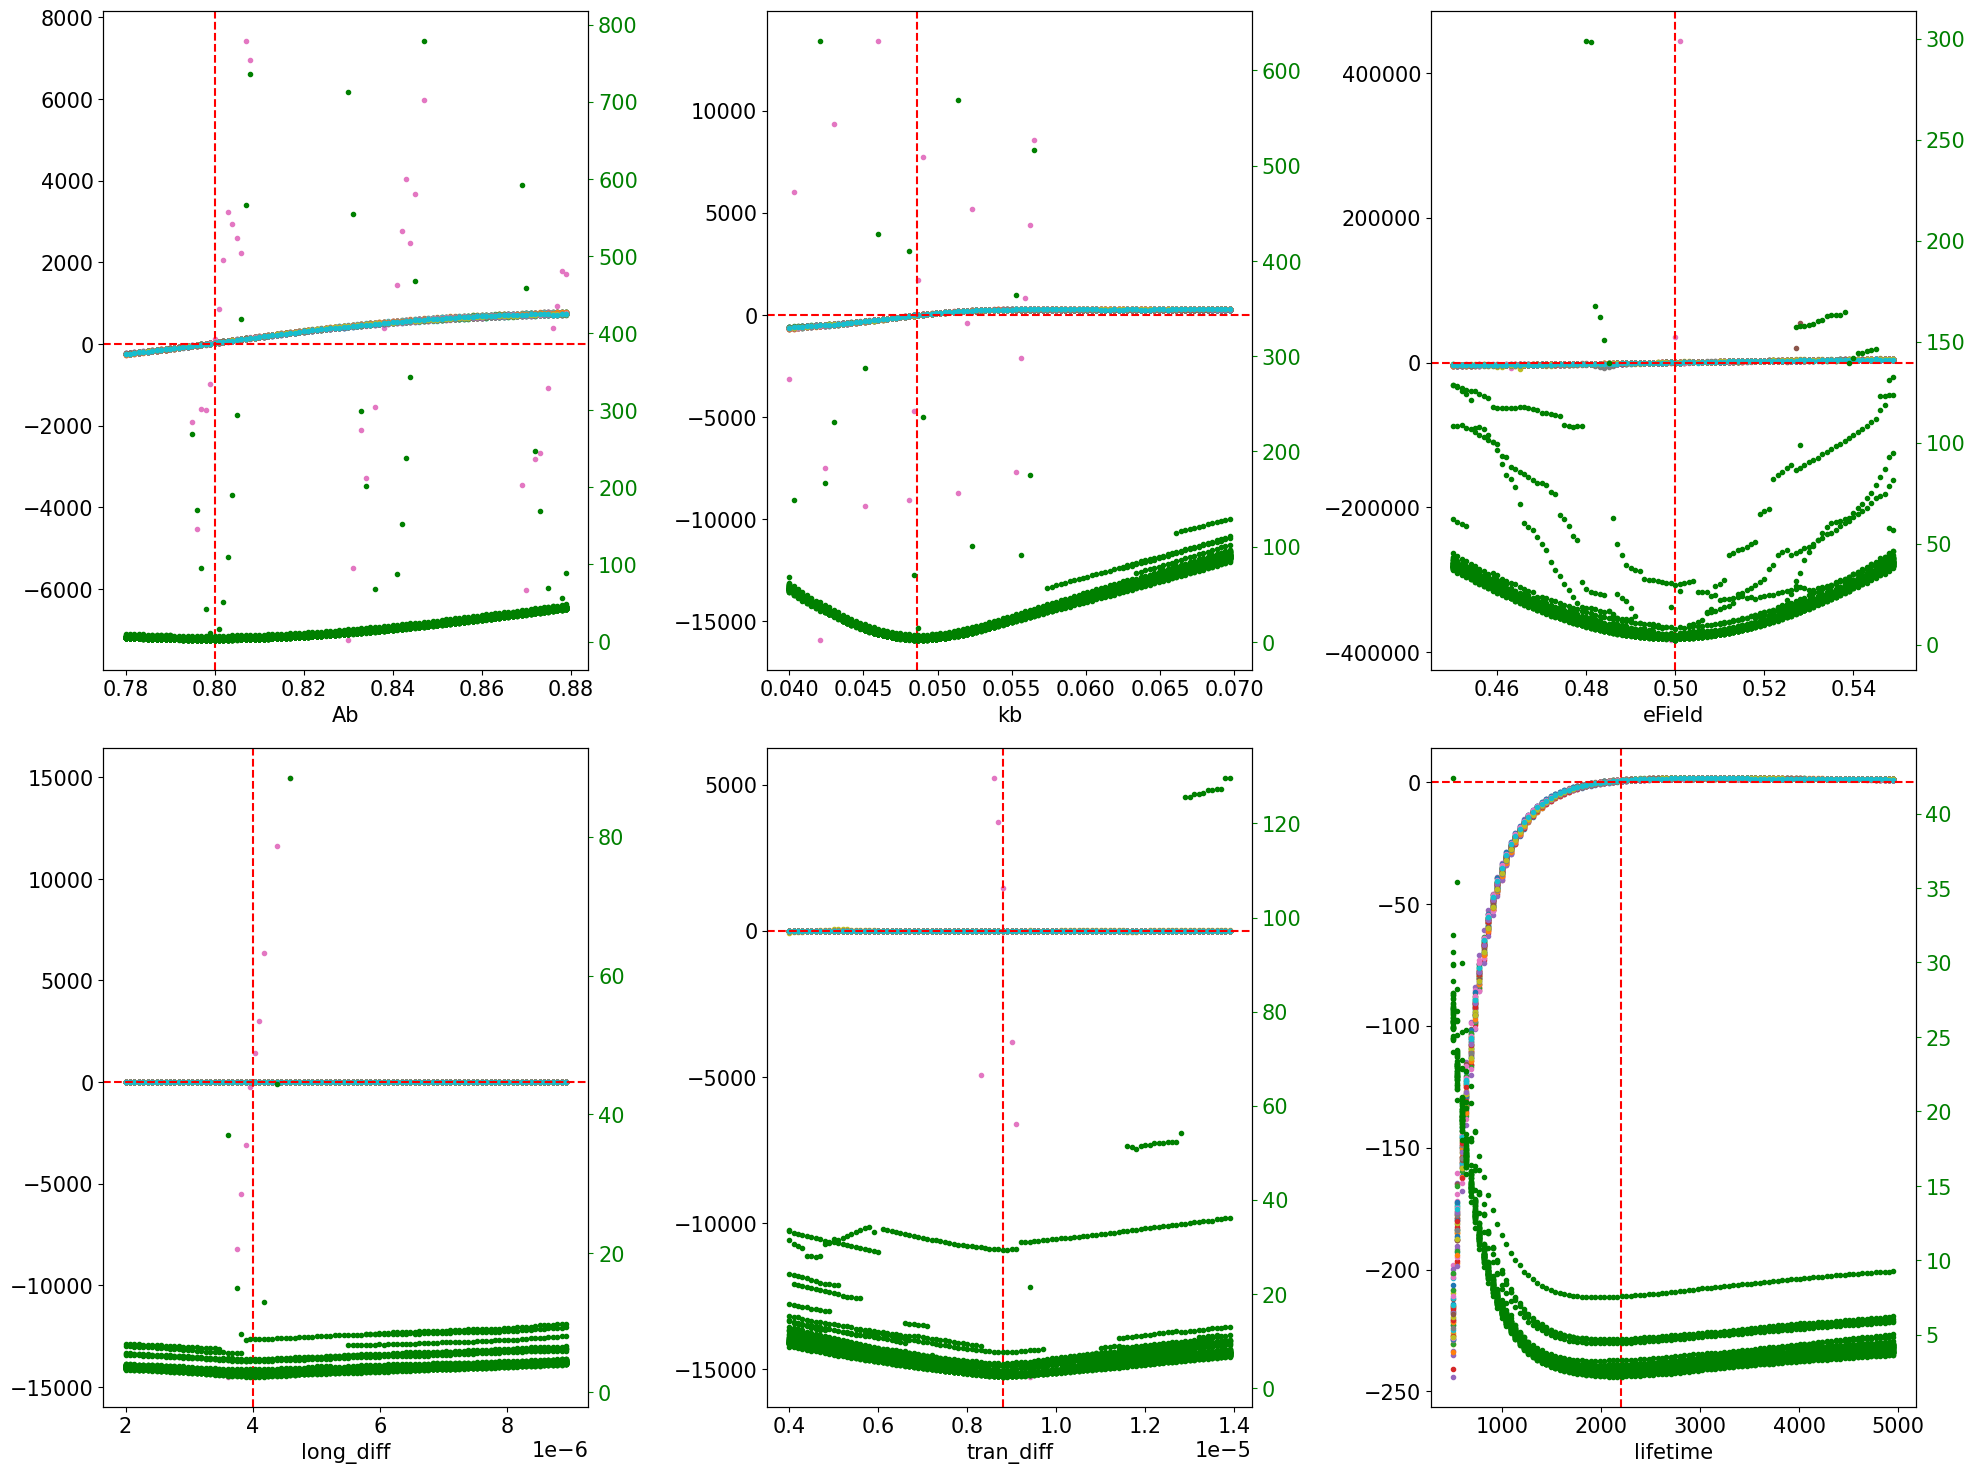

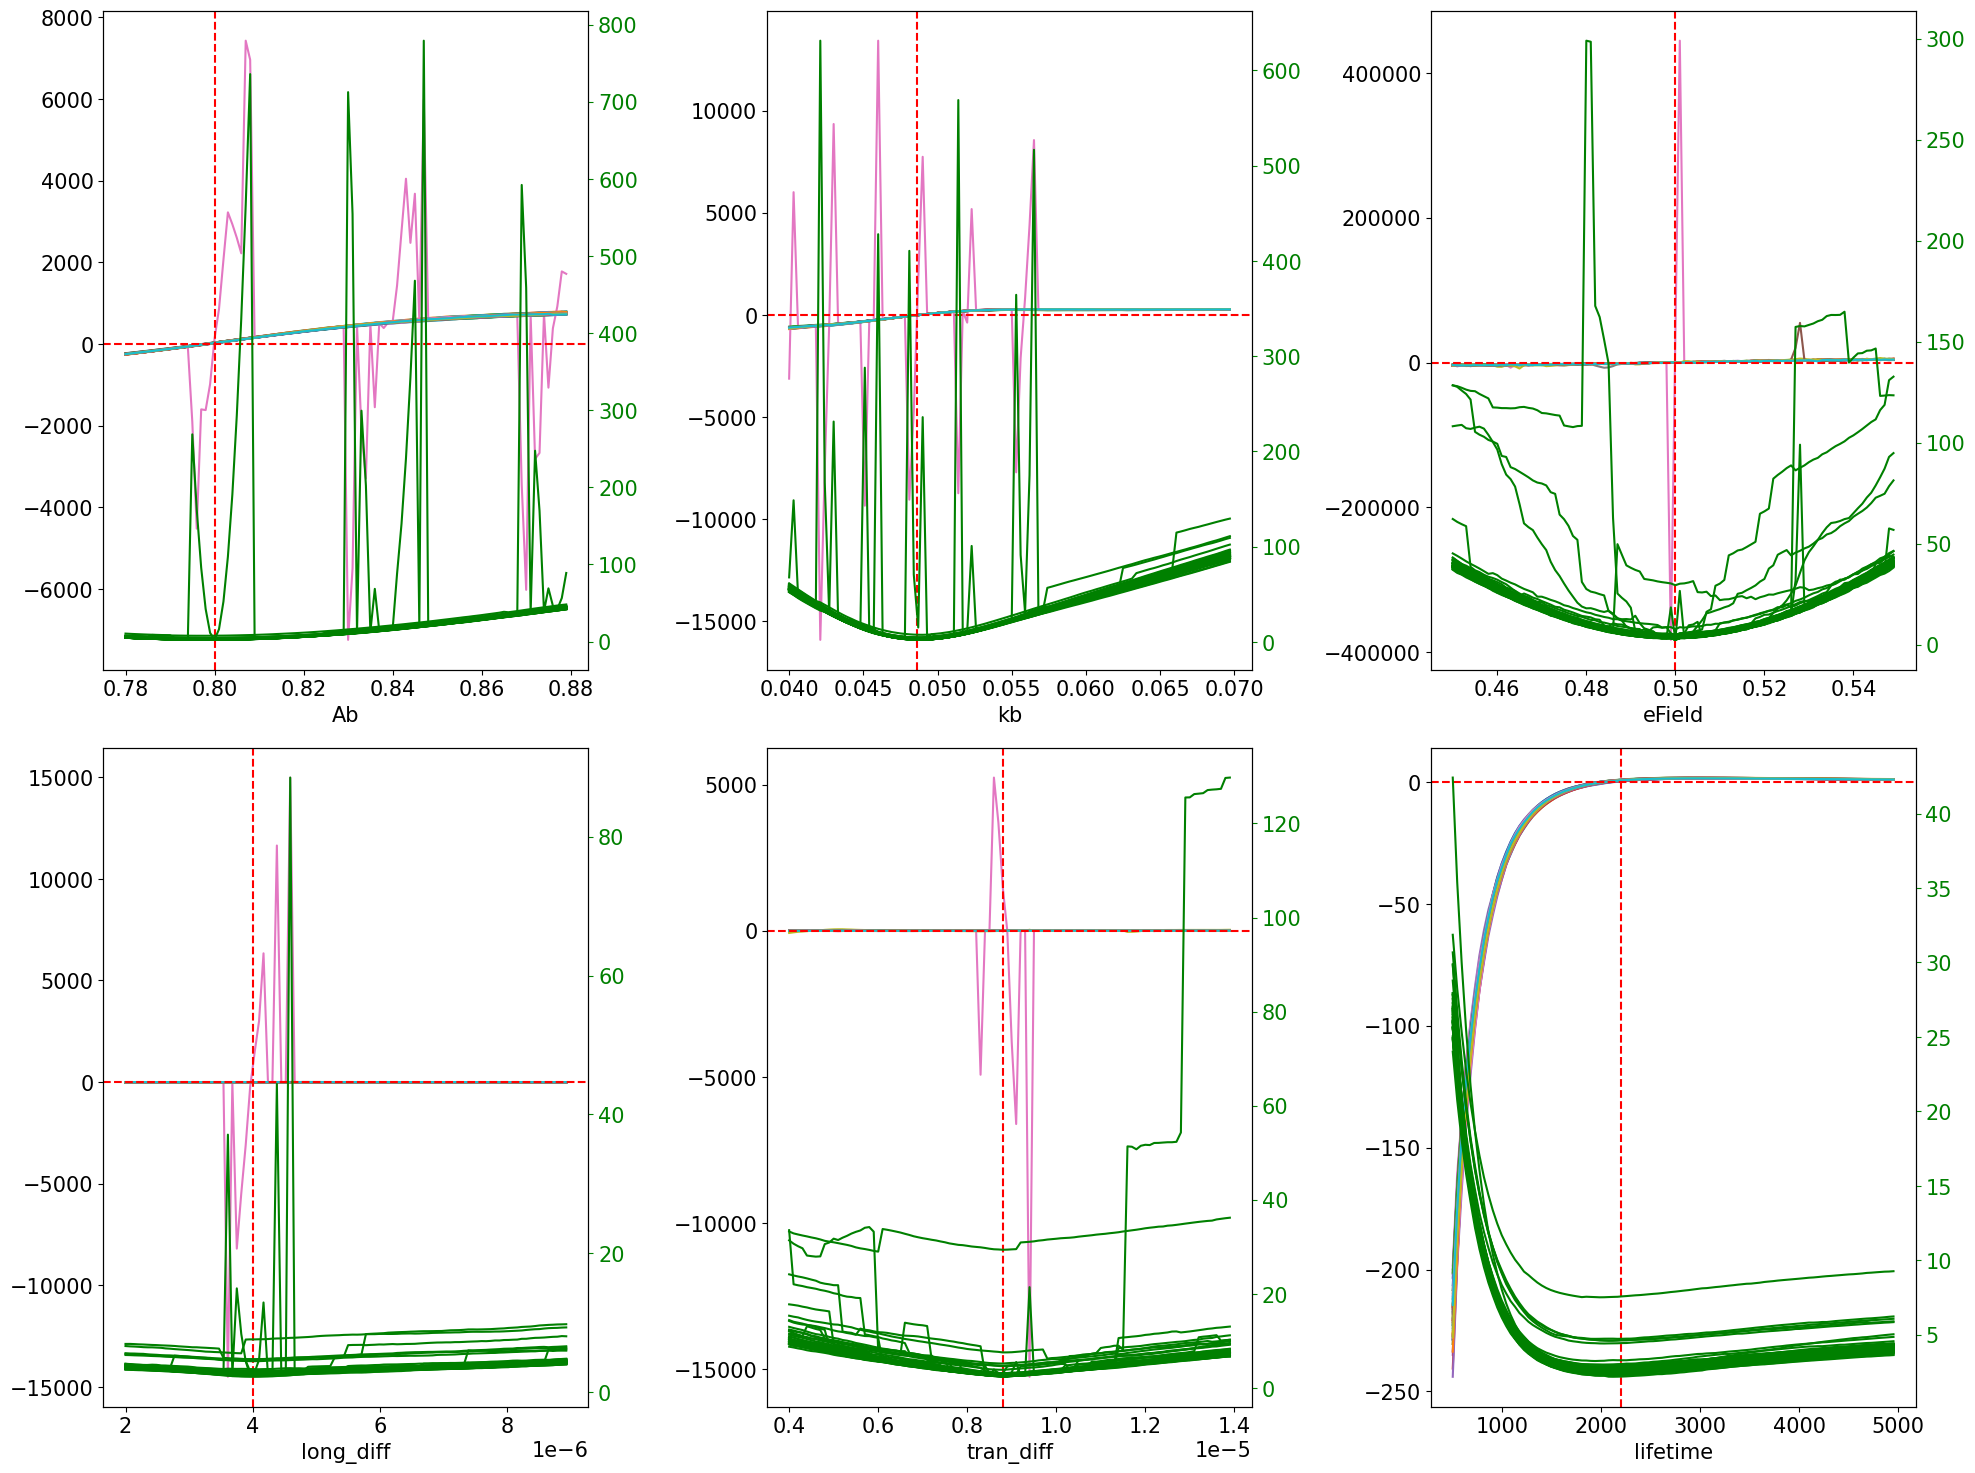

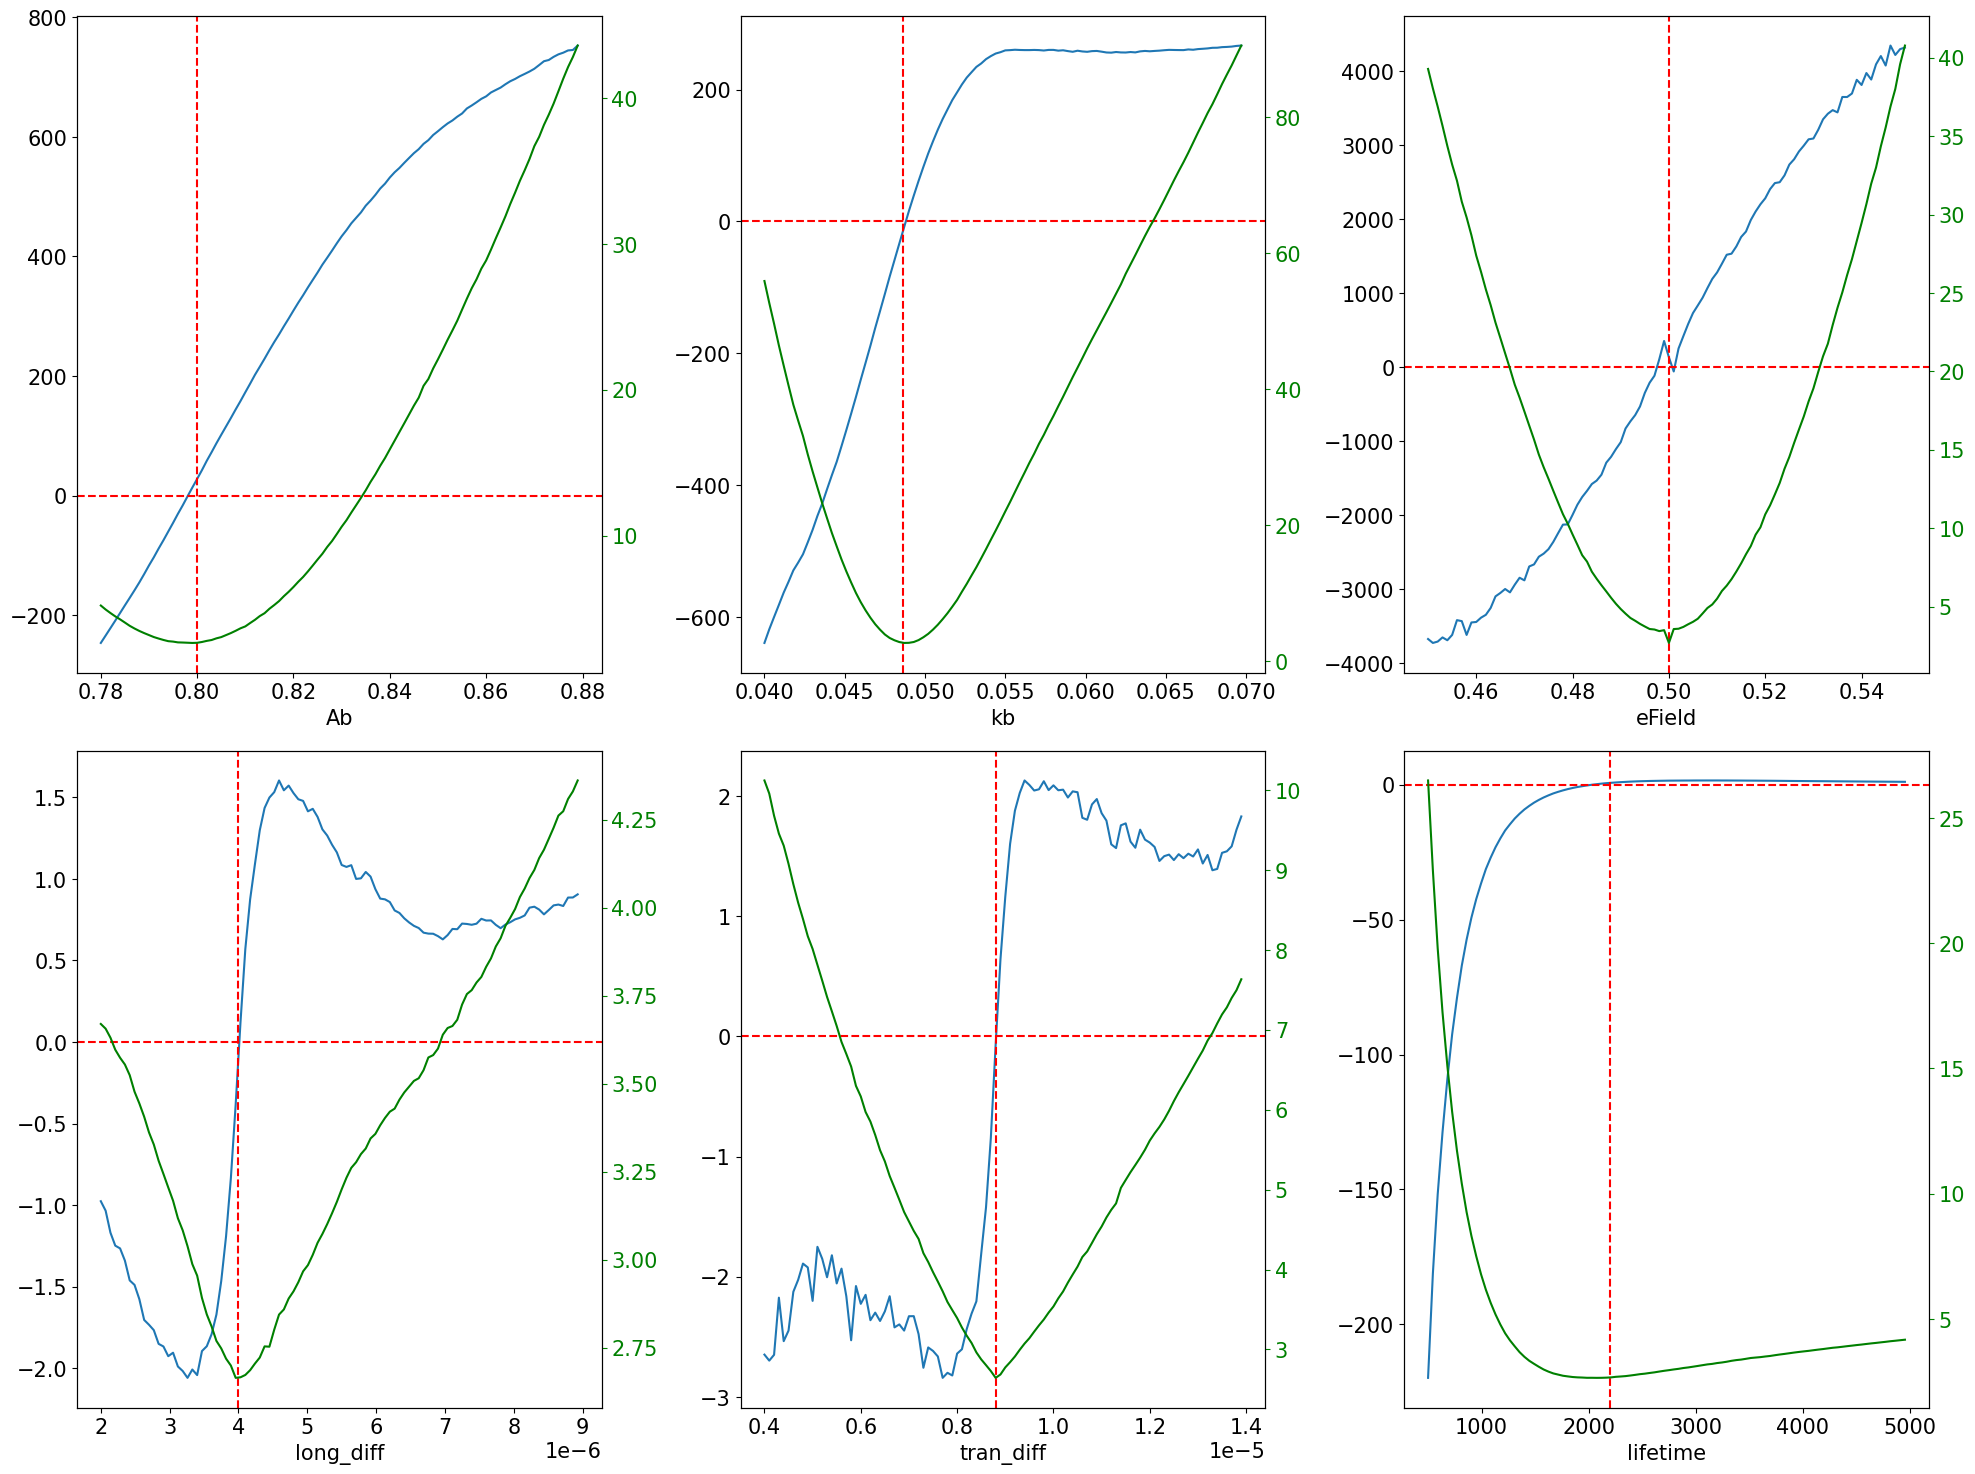

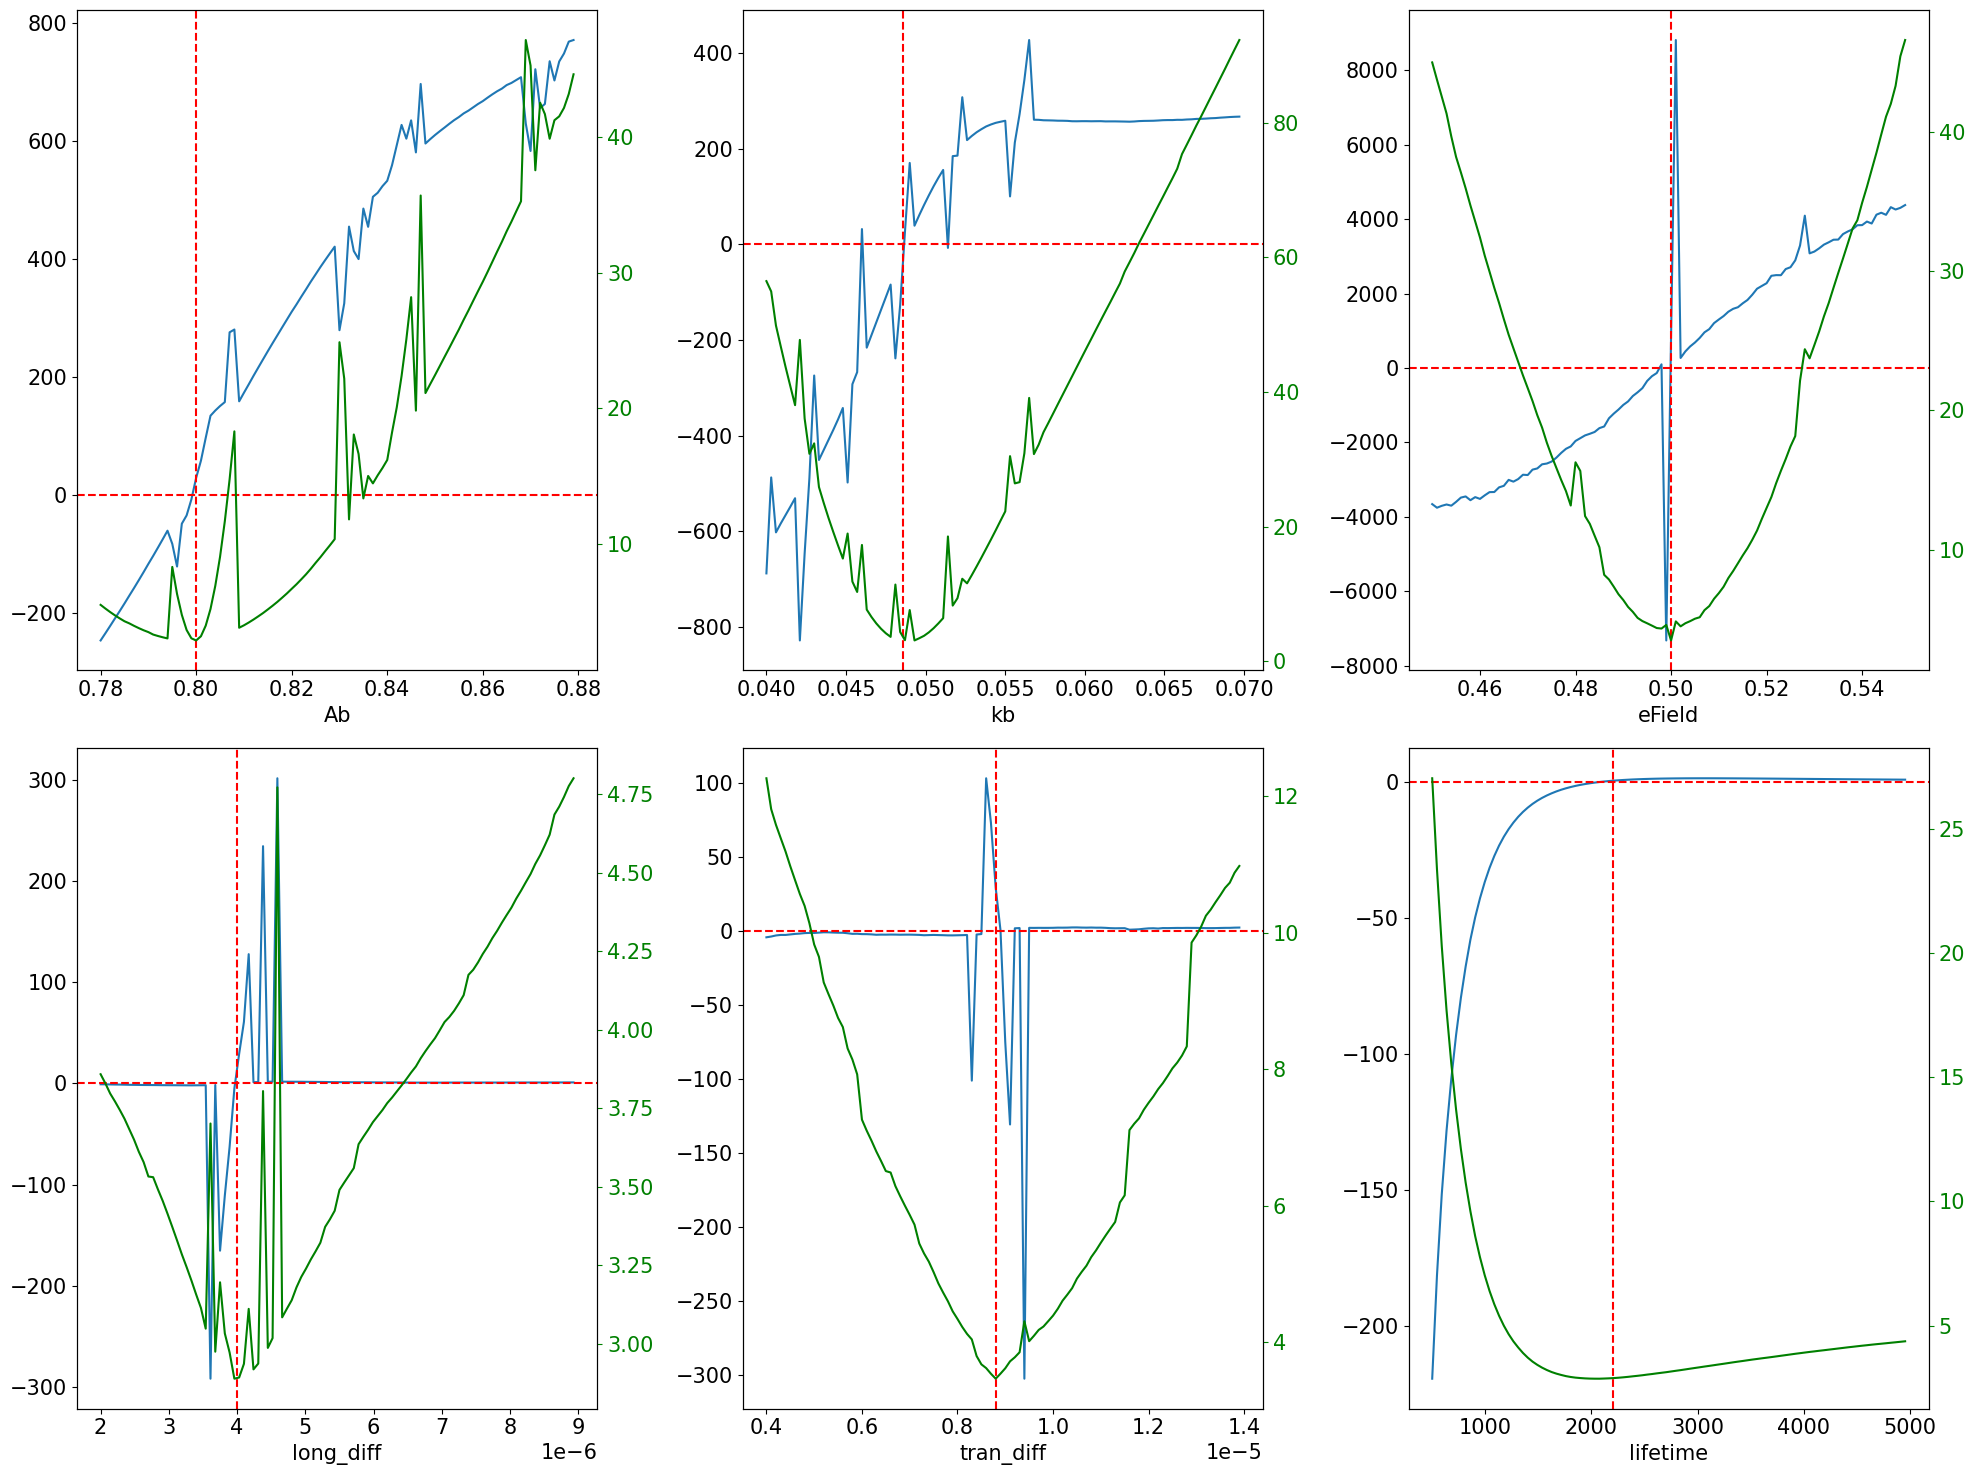

In [ ]:
# plot_style 1: plot all in dots | 2: plot all in lines | 3: median | 4: mean
def plot_gradient_scan(fname, ax=None, plot_style=0):
    
    with open(fname, 'rb') as f:
        results = pickle.load(f)    
    # print_config(results['config'])    
    params = [key.replace('_grad', '') for key in results.keys() if '_grad' in key]
    nb_params = len(params)
    assert(nb_params == 1)
    param = params[0]

    target = results[f"{param}_target"]

    global st_bt
    global st_iter
    global st_nbt
    global st_nsp
    global st_lr
    st_bt = vars(results['config'])['max_batch_len']
    st_iter = vars(results['config'])['iterations']    
    st_lr = vars(results['config'])['lr']    

    # nbatches = results['config'].max_nbatch
    
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    # # max_index = (len(results["losses_iter"])//nbatches)*nbatches

    # param_value = np.average(np.array(results[f"{param}_iter"][1:max_index + 1]).reshape(-1, nbatches), axis=1)
    param_value = np.sort(np.unique(results[f"{param}_iter"][1:]))
    nbatches = np.count_nonzero(results[f"{param}_iter"] == param_value[0])
    st_nbt = nbatches

    if plot_style == 1:
        style = "."
    else:
        style = "-"    

    max_index = (len(results["losses_iter"])//nbatches)*nbatches
    param_value = np.average(np.array(results[f"{param}_iter"][1:max_index + 1]).reshape(-1, nbatches), axis=1)
    
    if plot_style <=2:       
        grad = np.array(results[f"{param}_grad"][:max_index]).reshape(-1, nbatches)
        loss = np.array(results["losses_iter"][:max_index]).reshape(-1, nbatches)
    elif plot_style == 3:
        grad = np.nanmedian(np.array(results[f"{param}_grad"][:max_index]).reshape(-1, nbatches), axis=1)
        loss = np.nanmedian(np.array(results["losses_iter"][:max_index]).reshape(-1, nbatches), axis=1)
    elif plot_style == 4:
        grad = np.nanmean(np.array(results[f"{param}_grad"][:max_index]).reshape(-1, nbatches), axis=1)
        loss = np.nanmean(np.array(results["losses_iter"][:max_index]).reshape(-1, nbatches), axis=1)

    st_nsp = grad.shape[0]

    loss_min = ""
    gradient0 = ""
    if plot_style == 0:
        v_target = results[f'{param}_target'][0]
        v_loss_min = param_value[np.argmin(loss)]
        off_loss_min = (v_loss_min - v_target) / v_target * 100
        v_gradient0 = param_value[np.argmin(abs(grad))]
        off_gradient0 = (v_gradient0 - v_target) / v_target * 100
        loss_min = f" min: {np.min(loss):.2f} at {param} {Decimal(v_loss_min):.3E} \n (target: {Decimal(v_target):.3E}, offset {off_loss_min:.2f}%)"
        gradient0 = f" ~0 at {param} {Decimal(v_gradient0):.3E} \n (target: {Decimal(v_target):.3E}, offset {off_gradient0:.2f}%)"
        
    l1 = ax.plot(param_value, grad, style, label=f"gradient{gradient0}")
    ax2 = ax.twinx()
    ax2.tick_params(axis='y', colors='green')

    l2 = ax2.plot(param_value, loss, style, color='green', label=f"loss{loss_min}")
    l3 = ax.axvline(target, color='red', linestyle="--", label='target')
    l4 = ax.axhline(0, color='red', linestyle="--", label='target')

    lns = l1 + l2 + [l3]
    labs = [l.get_label() for l in lns]
    if plot_style == 0:
        ax2.legend(lns, labs, loc="upper right")
        # ax2.legend(lns, labs, loc=0)
    ax.set_xlabel(param)
    # ax.set_xlim([results[f'{param}_target'][0]*0.98, results[f'{param}_target'][0]*1.02])

list_of_files = glob.glob('fit_result/fit_stability/*iter5000*p_1E5*scan_noise_tgt_*bt2000*.pkl')
params= ["Ab", "kb", "eField", "long", "tran", "lifetime"]
latest_files = sorted(list_of_files, key=lambda x: params.index(x.split("_")[4]))
# latest_files = sorted(list_of_files, key=os.path.getctime)[-9:]




## 1 all dots
fig, axs = plt.subplots(2, 3, figsize=(20, 15))

for i, f in enumerate(latest_files):
    ax = axs[i//3, i%3]
    plot_gradient_scan(f, ax, 1)
fig.tight_layout()
# fig.savefig(f"plots/gradient_scan_noise_tgt_p_1E5_bt{st_bt}_iter{st_iter}_nbt{st_nbt}_nsp{st_nsp}_lr{st_lr}_dots.pdf")

## 2 all lines
fig, axs = plt.subplots(2, 3, figsize=(20, 15))

for i, f in enumerate(latest_files):
    ax = axs[i//3, i%3]
    plot_gradient_scan(f, ax, 2)
fig.tight_layout()
# fig.savefig(f"plots/gradient_scan_noise_tgt_p_1E5_bt{st_bt}_iter{st_iter}_nbt{st_nbt}_nsp{st_nsp}_lr{st_lr}_lines.pdf")

## 3 median
fig, axs = plt.subplots(2, 3, figsize=(20, 15))

for i, f in enumerate(latest_files):
    ax = axs[i//3, i%3]
    plot_gradient_scan(f, ax, 3)
fig.tight_layout()
# fig.savefig(f"plots/gradient_scan_noise_tgt_p_1E5_bt{st_bt}_iter{st_iter}_nbt{st_nbt}_nsp{st_nsp}_lr{st_lr}_median.pdf")

## 4 mean
fig, axs = plt.subplots(2, 3, figsize=(20, 15))

for i, f in enumerate(latest_files):
    ax = axs[i//3, i%3]
    plot_gradient_scan(f, ax, 4)
fig.tight_layout()
# fig.savefig(f"plots/gradient_scan_noise_tgt_p_1E5_bt{st_bt}_iter{st_iter}_nbt{st_nbt}_nsp{st_nsp}_lr{st_lr}_mean.pdf")

Namespace(param_list=['Ab'], input_file_sim='/sdf/group/neutrino/cyifan/muon-sim/fake_data_S1/edepsim_p_only_active_vol_5000.h5', input_file_tgt='/sdf/group/neutrino/cyifan/muon-sim/fake_data_S1/edepsim_p_only_active_vol_5000.h5', detector_props='larndsim/detector_properties/module0.yaml', pixel_layouts='larndsim/pixel_layouts/multi_tile_layout-2.2.16.yaml', load_checkpoint=None, num_workers=0, lr=10.0, batch_sz=1, epochs=100, seed=0, data_seed=1, seed_init=30, vary_init=False, data_sz=-1, no_noise=False, no_noise_target=False, no_noise_guess=True, data_shuffle=False, save_freq=10, random_ntrack=True, track_len_sel=2.0, max_abs_costheta_sel=0.966, min_abs_segz_sel=15.0, track_z_bound=28.0, out_label='Ab_p_5E3_6par_noise_tgt_no_clip_bt800_tgtsd0_dtsd1_adam_chamfer_3d_test5_adc48a69-2a54-4f00-877c-08fa150bde62', test_name='fit_stability', fixed_range=None, norm_scheme='divide', max_clip_norm_val=1.0, clip_from_range=False, optimizer_fn='Adam', lr_scheduler='exponential_decay', lr_kw={'de

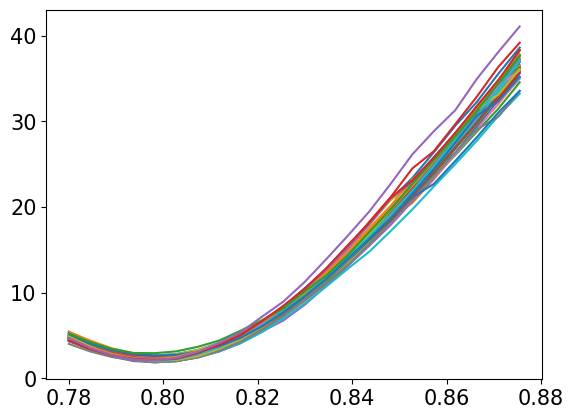

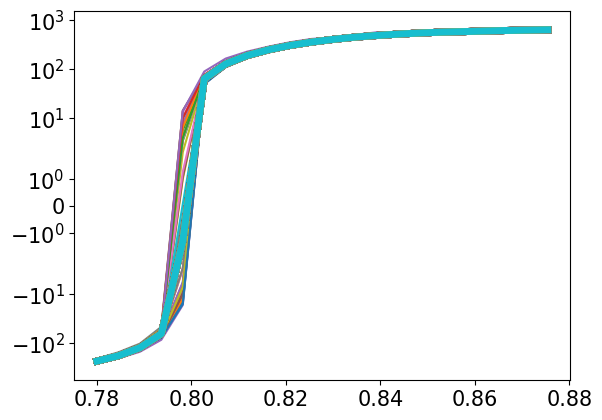

In [ ]:
list_of_files = glob.glob('fit_result/fit_stability/*scan*.pkl')
latest_file = sorted(list_of_files, key=os.path.getctime)[-1]
# latest_file = sorted(list_of_files, key=os.path.getctime)[-8]

with open(latest_file, 'rb') as f:
# with open(list_of_files, 'rb') as f:
    results = pickle.load(f)

params = [key for key in results.keys() if f'{key}_iter' in results.keys()]
params.remove('losses')

# nb_params = len(params)
# assert(nb_params == 1)
param = params[0]

fig = plt.figure()

param_value = np.sort(np.unique(results[f"{param}_iter"][1:]))
nbatches = np.count_nonzero(results[f"{param}_iter"] == param_value[0])
max_index = (len(results["losses_iter"])//nbatches)*nbatches
param_value = np.array(results[f"{param}_iter"][1:max_index + 1]).reshape(-1, nbatches)
loss = np.array(results["losses_iter"][:max_index]).reshape(-1, nbatches)
grad = np.array(results[f"{param}_grad"][:max_index]).reshape(-1, nbatches)

grad_mean = np.nanmean(grad, axis=1)

plt.plot(param_value, loss);
fig = plt.figure()
plt.plot(param_value, grad);
plt.plot(param_value, grad_mean, linewidth=5);
plt.yscale('symlog')
# plt.xlim(-1, 1)
print(results['config'])

# 
# # pprint(results[f"{param}_grad"][:41])
# l1 = ax.plot(param_value, grad, label="gradient")
# ax2 = ax.twinx()
# ax2.tick_params(axis='y', colors='green')

# l2 = ax2.plot(param_value, loss, color='green', label="loss")
# l3 = ax.axvline(target, color='red', label='target')
# l4 = ax.axhline(0, color='red', label='target')

# lns = l1 + l2 + [l3]
# labs = [l.get_label() for l in lns]
# ax2.legend(lns, labs, loc=0)
# ax.set_xlabel(param)

# plt.plot(results['losses_iter'])
# # plt.yscale('log')
# print(getattr(results['config'], 'loss_fn'))

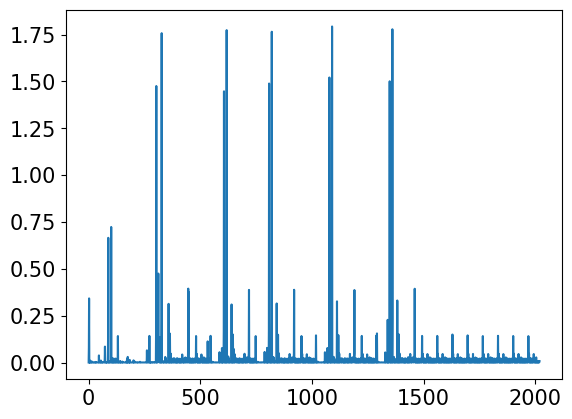

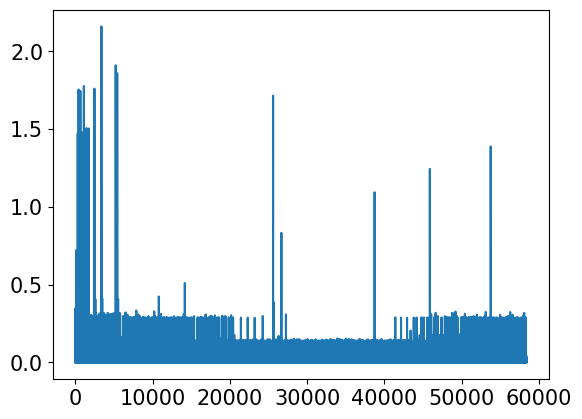

In [ ]:
times = np.loadtxt('times.txt')
plt.plot(times)
plt.figure()
times2 = np.loadtxt('times2.txt')
plt.plot(times2)